# **Willapa River and South Fork data processing**

file / data frame naming convention: what trip the sensor was picked up on

#### **Import packages and functions**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from scipy.signal import savgol_filter

#### **Load in files**

In [6]:
## References: NOAA MET data, USGS Willapa River gauge, and NOAA Toke Point gauge

nov25met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointNovMet.csv"
dec25met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointDecMet.csv"
jan26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointJanMet.csv"
feb26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointFebMet.csv"
mar26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointMarMet.csv"
apr26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointAprMet.csv"

usgs_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/willapariver_usgs_nov25toapr26.csv"

TPnov_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPnov.csv"
TPdec_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPdec.csv"
TPjan_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPjan.csv"
TPfeb_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPfeb.csv"
TPmar_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPmar.csv"
TPapr_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPapr.csv"

## Our data

wr01_novdec_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/BendiksenNovDec.xlsx"
wr01_janfeb_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/BendiksenJanFeb.xlsx"
wr01_marapr_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/BendiksenMarApr.xlsx"
wr02_novdec_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/RaymondNovDec.xlsx"
wr02_janfeb_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/RaymondJanFeb.xlsx"
wr02_marapr_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/RaymondMarApr.xlsx"
wr03_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR03_260308201320_FS029.CSV"
wr04_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR04_260308201401_FS064.CSV"
wr06_p1_d5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_InSitu632743brackish_2026-01-11_13-47-47-563.csv"
wr06_p2_d5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_InSitu642743brackishJan11dep_2026-03-08_13-08-58-922.txt"
wr06_ctd_d5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_RED_030826.txt"
wr06_ctd_d3_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/Copy of CTD_WR06_12.14retrieval.txt"
wr07_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/WR07_CTD.txt"
wr08_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/CTD2004_WR08_012826.txt"

sf01_d4_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/SF01_D4_FS041.CSV"
sf01_d5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/SF01_260308202720_FS041.CSV"
sf02_d4_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/SF02_260112134240_FS040.CSV"
sf03_d5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/SF03_SashaAlexFieldDayHOBO_030826.csv"

ss01_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/D5_hobo1126515downstreamskidmore.csv" # GMT and temp estimated at 10 deg C
ss02_D4_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/Floodplain_01_011126_D4retrieval.csv" # GMT and temp estimated at 10 deg C
ss02_D5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/Floodplain_01_030826_D5retrieval.csv" # GMT and temp estimated at 10 deg C
ss03_D4_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/SkidmoreSlough_02_011126_ACTUALLY_FLOODPLAIN03_SS03_D4retrieval.csv" # GMT and temp estimated at 10 deg C
ss03_D5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/D5_hobo1126511midskidmore_D5retrieval.csv" # GMT and temp estimated at 10 deg C;

#### **Read files to data frames**

In [8]:
## References: NOAA MET data, USGS Willapa River gauge, and NOAA Toke Point gauge

nov25met_df = pd.read_csv(nov25met_file)
dec25met_df = pd.read_csv(dec25met_file)
jan26met_df = pd.read_csv(jan26met_file)
feb26met_df = pd.read_csv(feb26met_file)
mar26met_df = pd.read_csv(mar26met_file)
apr26met_df = pd.read_csv(apr26met_file)
met_df = pd.concat([nov25met_df, dec25met_df, jan26met_df, feb26met_df, mar26met_df, apr26met_df], ignore_index=True) # LST time and metric

usgs_df = pd.read_csv(usgs_file)

TPnov_df = pd.read_csv(TPnov_file)
TPdec_df = pd.read_csv(TPdec_file)
TPjan_df = pd.read_csv(TPjan_file)
TPfeb_df = pd.read_csv(TPfeb_file)
TPmar_df = pd.read_csv(TPmar_file)
TPapr_df = pd.read_csv(TPapr_file)
TP_df = pd.concat([TPnov_df, TPdec_df, TPjan_df, TPfeb_df, TPmar_df, TPapr_df], ignore_index=True) # LST time and metric and NAVD datum

## Our data

wr01_novdec_df = pd.read_excel(wr01_novdec_file, skiprows=1)
wr01_janfeb_df = pd.read_excel(wr01_janfeb_file, skiprows=1,)
wr01_marapr_df = pd.read_excel(wr01_marapr_file, skiprows=1)
wr01_df = pd.concat([wr01_novdec_df, wr01_janfeb_df, wr01_marapr_df], ignore_index=True)
wr02_novdec_df = pd.read_excel(wr02_novdec_file, skiprows=1)
wr02_janfeb_df = pd.read_excel(wr02_janfeb_file, skiprows=1,)
wr02_marapr_df = pd.read_excel(wr02_marapr_file, skiprows=1)
wr02_df = pd.concat([wr02_novdec_df, wr02_janfeb_df, wr02_marapr_df], ignore_index=True)
wr03_df = pd.read_csv(wr03_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')
wr04_df = pd.read_csv(wr04_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')
wr06_p1_d5_df = pd.read_csv(wr06_p1_d5_file, skiprows=70)
wr06_p2_d5_df = pd.read_fwf(wr06_p2_d5_file, encoding='utf-16', skiprows=71)
wr06_ctd_d5_df = pd.read_csv(wr06_ctd_d5_file, skiprows=4, names=['Date', 'Time', 'Temp', 'SpCond', 'Sal', 'Press', 'Depth', 'Battery'])
wr06_ctd_d3_df = pd.read_csv(wr06_ctd_d3_file, sep=',', skiprows=[0, 2], header=0)
wr07_df = pd.read_csv(wr07_file, sep=',', skiprows=[0, 2], header=0)
wr08_df = pd.read_csv(wr08_file, sep=',', skiprows=[0, 2], header=0)

sf01_d4_df = pd.read_csv(sf01_d4_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')
sf01_d5_df = pd.read_csv(sf01_d5_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')
sf02_d4_df = pd.read_csv(sf02_d4_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')
sf03_d5_df = pd.read_csv(sf03_d5_file, encoding='latin-1', skiprows=1)

ss01_df = pd.read_csv(ss01_file, skiprows=1, usecols=range(3))
ss02_D4_df = pd.read_csv(ss02_D4_file, skiprows=1, usecols=range(3))
ss02_D5_df = pd.read_csv(ss02_D5_file, skiprows=1, usecols=range(3))
ss03_D4_df = pd.read_csv(ss03_D4_file, skiprows=1, usecols=range(3))
ss03_D5_df = pd.read_csv(ss03_D5_file, skiprows=1, usecols=range(3));

#### **Define helper functions**

In [10]:
# Handle NOAA met data

met_df["Datetime"] = pd.to_datetime(met_df["Date"].astype(str) + " " + met_df["Time (LST)"].astype(str), errors="coerce")
met_df = met_df.set_index("Datetime").sort_index()

# Convert to numeric and to Pa
met_df["Baro (Pa)"] = pd.to_numeric(met_df["Baro (mb)"], errors='coerce') * 100

# Create 5-minute baseline using Pa
met_df_5min = met_df['Baro (Pa)'].resample('5min').interpolate(method='linear')


def itp_noaa_metdata(met_5min_series, sensor_dt_array): 
    """
    Interpolate NOAA atm pressure from 5-min baseline to sensor timestamps

    Parameters:
    - NOAA meteorological dataframe interpolated to 5-min intervals
    - sensor datetime array

    Returns:
    - array of pressure values interpolated at sensor timestamps

    """

    sensor_dt = pd.DatetimeIndex(sensor_dt_array)
    all_times = met_5min_series.index.union(sensor_dt).unique().sort_values()
    combo = met_5min_series.reindex(all_times).interpolate(method="linear")
    
    itp_pressure = combo.loc[sensor_dt]

    return itp_pressure

In [11]:
# Take ftH2O or cmH2O array and create TWL [m] 

def cmH2O_to_Pa(pressure_cmH2O, temperature, salinity):
    """
    Convert pressure from cmH2O to Pascals, accounting for temperature and salinity.
    
    INPUTS
    pressure_cmH2O : (array) pressure readings in centimeters of water (cmH2O)
    temperature : (array) temperature readings in degrees Celsius
    salinity : constant salinity value in PSU
    
    OUTPUTS
    pressure_Pa : array-like
        Pressure in Pascals
    """
    # Constants
    g = 9.81  # gravitational acceleration (m/s²)
    cm_to_m = 0.01  # centimeters to meters conversion
    
    # Calculate density based on temperature and salinity
    rho = density(temperature, salinity)
    
    # Convert cmH2O to meters of water, then to Pascals
    # P = ρ * g * h
    pressure_Pa = rho * g * (pressure_cmH2O * cm_to_m)
    
    return pressure_Pa


def ftH2O_to_Pa(pressure_ftH2O, temperature, salinity):
    """
    Convert pressure from ftH2O to Pascals, accounting for temperature and salinity.
    
    INPUTS
    pressure_ftH2O : (array) pressure readings in feet of water (ftH2O)
    temperature : (array) temperature readings in degrees Celsius
    salinity : constant salinity value in PSU
    
    OUTPUTS
    pressure_Pa : array-like
        Pressure in Pascals
    """
    # Constants
    g = 9.81  # gravitational acceleration (m/s²)
    ft_to_m = 0.3048  # feet to meters conversion
    
    # Calculate density based on temperature and salinity
    rho = density(temperature, salinity)
    
    # Convert ftH2O to meters of water, then to Pascals
    # P = ρ * g * h
    pressure_Pa = rho * g * (pressure_ftH2O * ft_to_m)
    
    return pressure_Pa

In [12]:
# Handles density conversion in pressure --> TWL 

def density(T, S):
    """
    input: temperature array in deg celsius, constant salinity value in PSU
    output: density in kg/m^3
    """
    rho_fw = 1000 * (1 - ((T + 288.9414)/(508929.2*(T + 68.12963))) * (T - 3.9863)**2)
    rho_ew = rho_fw + (0.824 * S)
    return rho_ew

## **Willapa River**

### References

**USGS**

In [22]:
usgs_df['USGS DATETIME [PST]'] = usgs_df['time']
usgs_df['USGS TWL NAVD88 [m]'] = usgs_df['value']*0.3048

usgs_dt = usgs_df['USGS DATETIME [PST]']
usgs_dt = pd.to_datetime(usgs_dt, errors='coerce').dt.tz_localize(None)
usgs_twl = usgs_df['USGS TWL NAVD88 [m]']

usgs_df_new = usgs_df[['USGS DATETIME [PST]', 'USGS TWL NAVD88 [m]']]

usgs_df_new.head()

,USGS DATETIME [PST],USGS TWL NAVD88 [m]
0,2026-05-01 06:45:00+00:00,1.255776
1,2026-05-01 06:30:00+00:00,1.258824
2,2026-05-01 06:15:00+00:00,1.258824
3,2026-05-01 06:00:00+00:00,1.258824
4,2026-05-01 05:45:00+00:00,1.258824


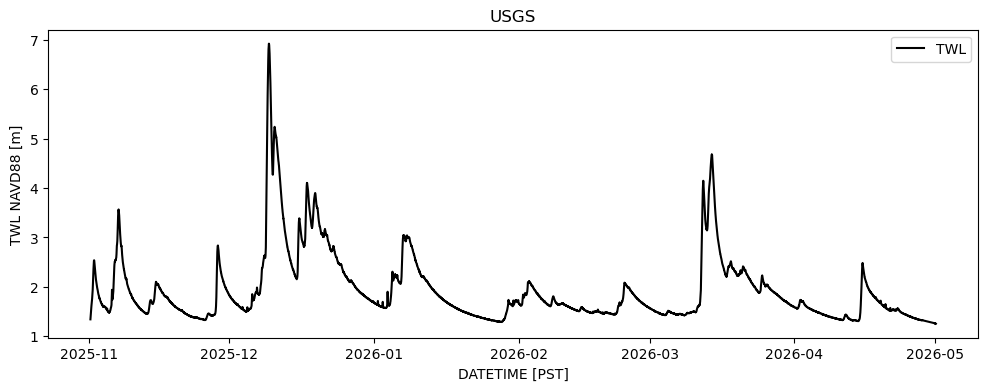

In [24]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(usgs_dt, usgs_twl, label='TWL', color='black')
ax.set_ylabel('TWL NAVD88 [m]')
ax.set_xlabel('DATETIME [PST]')
ax.set_title('USGS')
ax.legend();

**Toke Point**

In [27]:
TP_df['TP DATETIME [PST]'] = pd.to_datetime(TP_df['Date'] + ' ' + TP_df['Time (LST/LDT)'])
TP_df['TP TWL NAVD88 [m]'] = pd.to_numeric(TP_df['Verified (m)'], errors='coerce')

TP_dt = TP_df["TP DATETIME [PST]"]
TP_twl = TP_df["TP TWL NAVD88 [m]"]

TP_df_new = TP_df[['TP DATETIME [PST]', 'TP TWL NAVD88 [m]']]

TP_df_new.head()

,TP DATETIME [PST],TP TWL NAVD88 [m]
0,2025-11-06 00:00:00,2.478
1,2025-11-06 00:06:00,2.513
2,2025-11-06 00:12:00,2.549
3,2025-11-06 00:18:00,2.585
4,2025-11-06 00:24:00,2.616


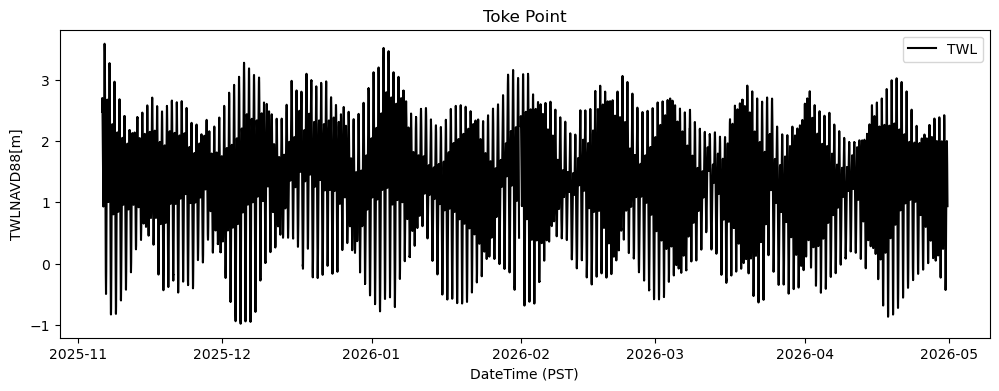

In [29]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(TP_dt, TP_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('Toke Point')
ax.legend();

### WR01

In [32]:
# data cleaning
wr01_df["WR01 TWL NAVD88 [m]"] = (wr01_df["Level/Stage (ft)"] * 0.3048) - 0.427  # in m NAVD88
wr01_df['WR01 DATETIME [PST]'] = pd.to_datetime(wr01_df["Date&Time"], format="%m/%d/%Y %I:%M:%S %p")
wr01_df = wr01_df.sort_values('WR01 DATETIME [PST]').reset_index(drop=True)
wr01_df = wr01_df.iloc[100:].reset_index(drop=True)
wr01_df["WR01 TWL [m]"] = wr01_df["Level/Stage (ft)"] * 0.3048
wr01_df["WR01 OFFSET [m]"] = -0.427
wr01_df.loc[(wr01_df['WR01 DATETIME [PST]'] >= '2025-12-05 08:55:00') & (wr01_df['WR01 DATETIME [PST]'] <= '2025-12-06 15:10:00'), 'WR01 TWL NAVD88 [m]'] = np.nan
wr01_dt = wr01_df['WR01 DATETIME [PST]']
wr01_twl = wr01_df["WR01 TWL NAVD88 [m]"]

wr01_df_new = wr01_df[['WR01 DATETIME [PST]', 'WR01 TWL [m]', 'WR01 OFFSET [m]', 'WR01 TWL NAVD88 [m]']]

wr01_df_new.head()

,WR01 DATETIME [PST],WR01 TWL [m],WR01 OFFSET [m],WR01 TWL NAVD88 [m]
0,2025-11-08 01:50:00,1.990344,-0.427,1.563344
1,2025-11-08 01:55:00,2.036064,-0.427,1.609064
2,2025-11-08 02:00:00,2.081784,-0.427,1.654784
3,2025-11-08 02:05:00,2.130552,-0.427,1.703552
4,2025-11-08 02:10:00,2.170176,-0.427,1.743176


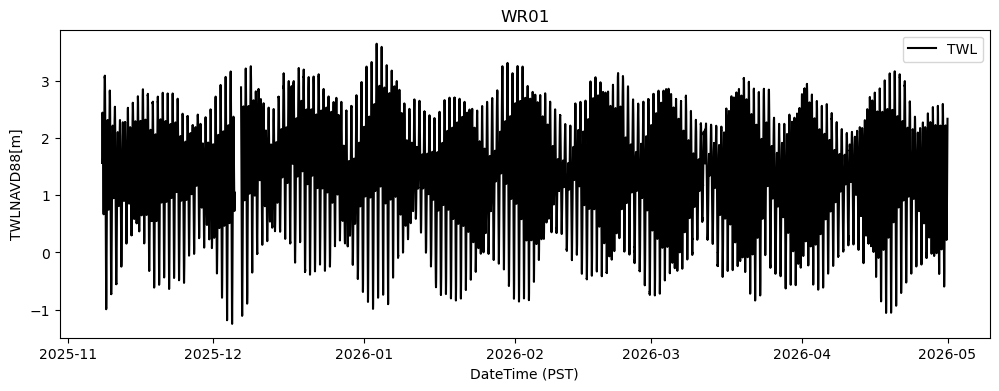

In [34]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(wr01_dt, wr01_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('WR01')
ax.legend();

### WR02

In [37]:
wr02_df["WR02 TWL NAVD88 [m]"] = (wr02_df["Level/Stage (ft)"] * 0.3048) - 0.427
wr02_df['WR02 DATETIME [PST]'] = pd.to_datetime(wr02_df["Date&Time"], format="%m/%d/%Y %I:%M:%S %p")
wr02_df = wr02_df.sort_values('WR02 DATETIME [PST]').reset_index(drop=True)
wr02_df = wr02_df.iloc[100:].reset_index(drop=True)
wr02_df["WR02 TWL [m]"] = wr02_df["Level/Stage (ft)"] * 0.3048
wr02_df["WR02 OFFSET [m]"] = -0.427
wr02_df.loc[(wr02_df['WR02 DATETIME [PST]'] >= '2025-12-05 08:55:00') & (wr02_df['WR02 DATETIME [PST]'] <= '2025-12-06 15:10:00'), 'WR02 TWL NAVD88 [m]'] = np.nan
wr02_dt = wr02_df['WR02 DATETIME [PST]']
wr02_twl = wr02_df["WR02 TWL NAVD88 [m]"]

wr02_df_new = wr02_df[['WR02 DATETIME [PST]', 'WR02 TWL [m]', 'WR02 OFFSET [m]', 'WR02 TWL NAVD88 [m]']]

wr02_df_new.head()

,WR02 DATETIME [PST],WR02 TWL [m],WR02 OFFSET [m],WR02 TWL NAVD88 [m]
0,2025-11-07 22:00:00,0.091440,-0.427,-0.335560
1,2025-11-07 22:05:00,0.103632,-0.427,-0.323368
2,2025-11-07 22:10:00,0.134112,-0.427,-0.292888
3,2025-11-07 22:15:00,0.164592,-0.427,-0.262408
4,2025-11-07 22:20:00,0.201168,-0.427,-0.225832


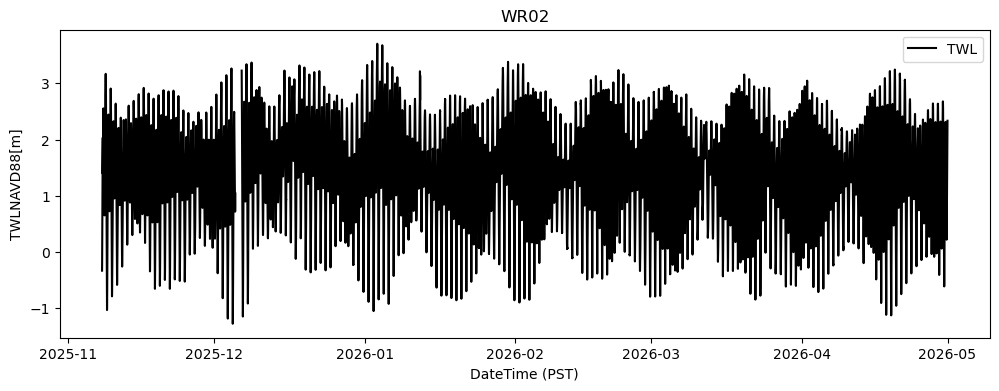

In [39]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(wr02_dt, wr02_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('WR02')
ax.legend();

### WR03

In [160]:
## Trim data

wr03_df.head() # 35208
wr03_df_trim = wr03_df[26:35200].copy()
wr03_df_trim['Date/time'] = pd.to_datetime(wr03_df_trim['Date/time'])
wr03_df_trim.iloc[19080-26:19114-26, wr03_df_trim.columns.get_loc('Pressure[cmH2O]')] = np.nan  # erroneous values
wr03_df_trim.iloc[11052-26:11060-26, wr03_df_trim.columns.get_loc('Pressure[cmH2O]')] = np.nan  # erroneous values
wr03_df.head()

,Date/time,Pressure[cmH2O],Temperature[°C]
0,2025/11/06 14:00:00,1032.450,13.257
1,2025/11/06 14:05:00,1032.158,12.867
2,2025/11/06 14:10:00,1032.275,12.577
3,2025/11/06 14:15:00,1032.158,12.367
4,2025/11/06 14:20:00,1032.450,12.250


In [172]:
## Trim data
wr03_df.head() # 35208
wr03_df_trim = wr03_df[26:35200].copy()
wr03_df_trim['Date/time'] = pd.to_datetime(wr03_df_trim['Date/time'])
wr03_df_trim.iloc[19080-26:19114-26, wr03_df_trim.columns.get_loc('Pressure[cmH2O]')] = np.nan  # erroneous values
wr03_df_trim.iloc[11052-26:11060-26, wr03_df_trim.columns.get_loc('Pressure[cmH2O]')] = np.nan  # erroneous values

## Convert to TWL NAVD88
wr03_df_trim['WR03 ABS PRESS [cmH2O]'] = wr03_df_trim['Pressure[cmH2O]'].interpolate(method='linear')
wr03_df_trim['Date/time'] = pd.to_datetime(wr03_df_trim['Date/time'])
wr03_df_trim['WR03 DATETIME [PST]'] = wr03_df_trim['Date/time'].dt.tz_localize(
    'US/Pacific', nonexistent='shift_forward', ambiguous='NaT'
).dt.tz_localize(None)
g = 9.81 # m/s^2
salinity = 0.5 # PSU approx
wr03_df_trim["Rho[kg/m^3]"] = density(wr03_df_trim["Temperature[°C]"], salinity)
wr03_absp_Pa = cmH2O_to_Pa(wr03_df_trim["WR03 ABS PRESS [cmH2O]"], wr03_df_trim["Temperature[°C]"], salinity)
wr03_df_trim["WR03 ABS PRESS [Pa]"] = wr03_absp_Pa
wr03_itp_metp = itp_noaa_metdata(met_df_5min, wr03_df_trim["Date/time"])
wr03_df_trim["WR03 MET PRESS [Pa]"] = wr03_itp_metp.values
wr03_df_trim["WR03 TWL [m]"] = (wr03_df_trim["WR03 ABS PRESS [Pa]"] - wr03_df_trim["WR03 MET PRESS [Pa]"]) / (wr03_df_trim["Rho[kg/m^3]"] * g)
wr03_df_trim["WR03 TWL [m]"] = np.where(wr03_df_trim["WR03 TWL [m]"] < 0, np.nan, wr03_df_trim["WR03 TWL [m]"])

## Apply split NAVD88 offsets based on deployment period
offset_pre  = -1.164  # before retrieval
offset_post = -1.108  # after redeployment at new elevation

wr03_df_trim['WR03 OFFSET [m]'] = np.where(
    wr03_df_trim['WR03 DATETIME [PST]'] <= pd.Timestamp('2025-12-14 14:55:00'),
    offset_pre,
    offset_post
)
wr03_df_trim["WR03 TWL NAVD88 [m]"] = wr03_df_trim["WR03 TWL [m]"] + wr03_df_trim['WR03 OFFSET [m]']

## Null out retrieval window
wr03_df_trim.loc[
    (wr03_df_trim['WR03 DATETIME [PST]'] >= pd.Timestamp('2025-12-14 15:00:00')) &
    (wr03_df_trim['WR03 DATETIME [PST]'] <= pd.Timestamp('2025-12-14 15:45:00')),
    'WR03 TWL NAVD88 [m]'
] = np.nan

wr03_dt = wr03_df_trim["WR03 DATETIME [PST]"]
wr03_twl = wr03_df_trim["WR03 TWL NAVD88 [m]"]
wr03_df_trim['WR03 TEMP [degC]'] = wr03_df_trim["Temperature[°C]"]
wr03_df_new = wr03_df_trim[['WR03 DATETIME [PST]', 'WR03 ABS PRESS [cmH2O]', 'WR03 ABS PRESS [Pa]', 'WR03 TEMP [degC]', 'WR03 MET PRESS [Pa]', 'WR03 TWL [m]', 'WR03 OFFSET [m]', 'WR03 TWL NAVD88 [m]']]

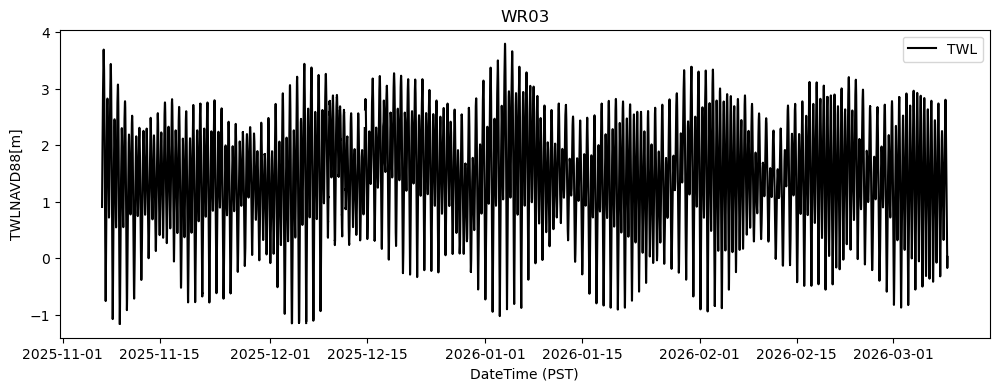

In [178]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(wr03_dt, wr03_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('WR03')
ax.legend();

### WR04

In [49]:
wr04_df.head()
wr04_df_trim = wr04_df[20:35194].copy()
wr04_df_trim['Date/time'] = pd.to_datetime(wr04_df_trim['Date/time'])
wr04_df_trim.iloc[19063:19096, wr04_df_trim.columns.get_loc('Pressure[cmH2O]')] = np.nan # erroneous values

In [51]:
## Convert to TWL NAVD88

wr04_df_trim['WR04 ABS PRESS [cmH2O]'] = wr04_df_trim['Pressure[cmH2O]'].interpolate(method='linear')
wr04_df_trim['Date/time'] = pd.to_datetime(wr04_df_trim['Date/time'])
wr04_df_trim['WR04 DATETIME [PST]'] = wr04_df_trim['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

g = 9.81 # m/s^2
salinity = 0.5 # PSU approx
wr04_df_trim["Rho[kg/m^3]"] = density(wr04_df_trim["Temperature[°C]"], salinity)

wr04_absp_Pa = cmH2O_to_Pa(wr04_df_trim["WR04 ABS PRESS [cmH2O]"], wr04_df_trim["Temperature[°C]"], salinity)
wr04_df_trim["WR04 ABS PRESS [Pa]"] = wr04_absp_Pa

wr04_itp_metp = itp_noaa_metdata(met_df_5min, wr04_df_trim["WR04 DATETIME [PST]"])
wr04_df_trim["WR04 MET PRESS [Pa]"] = wr04_itp_metp.values

wr04_df_trim["WR04 TWL [m]"] = (wr04_df_trim["WR04 ABS PRESS [Pa]"] - wr04_df_trim["WR04 MET PRESS [Pa]"]) / (wr04_df_trim["Rho[kg/m^3]"] * g)
wr04_df_trim["WR04 TWL [m]"] = np.where(wr04_df_trim["WR04 TWL [m]"] < 0, np.nan, wr04_df_trim["WR04 TWL [m]"])

wr04_df_trim["WR04 TWL NAVD88 [m]"] = wr04_df_trim["WR04 TWL [m]"] - 1.046 # sticking w/ initial elev and ignoring 0.5" slide for now

wr04_df_trim['WR04 OFFSET [m]'] = - 1.046
wr04_df_trim['WR04 TEMP [degC]'] = wr04_df_trim["Temperature[°C]"]

wr04_dt = wr04_df_trim["WR04 DATETIME [PST]"]
wr04_twl = wr04_df_trim["WR04 TWL NAVD88 [m]"]

wr04_df_new = wr04_df_trim[['WR04 DATETIME [PST]', 'WR04 ABS PRESS [cmH2O]', 'WR04 ABS PRESS [Pa]', 'WR04 TEMP [degC]', 'WR04 MET PRESS [Pa]', 'WR04 TWL [m]', 'WR04 OFFSET [m]', 'WR04 TWL NAVD88 [m]']]

wr04_df_new.head()

,WR04 DATETIME [PST],WR04 ABS PRESS [cmH2O],WR04 ABS PRESS [Pa],WR04 TEMP [degC],WR04 MET PRESS [Pa],WR04 TWL [m],WR04 OFFSET [m],WR04 TWL NAVD88 [m]
20,2025-11-06 07:40:00,1214.392,119141.143654,10.673,101153.333333,1.833477,-1.046,0.787477
21,2025-11-06 07:45:00,1215.208,119221.199495,10.673,101150.000000,1.841977,-1.046,0.795977
22,2025-11-06 07:50:00,1216.783,119375.903688,10.657,101146.666667,1.858082,-1.046,0.812082
23,2025-11-06 07:55:00,1219.292,119622.136981,10.650,101143.333333,1.883519,-1.046,0.837519
24,2025-11-06 08:00:00,1222.850,119971.007781,10.667,101140.000000,1.919422,-1.046,0.873422


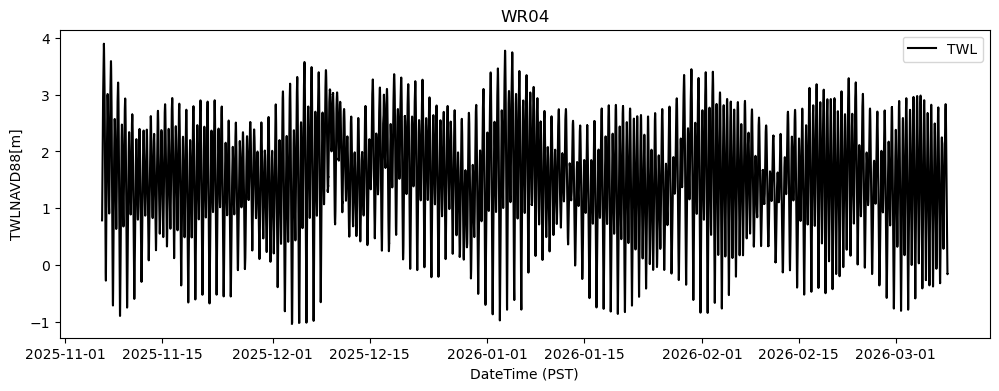

In [53]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(wr04_dt, wr04_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('WR04')
ax.legend();

### WR06

In [56]:
# pressure p1
# this was the other in-situ that had the time offset!!
wr06_p1_d5_df = pd.read_csv(wr06_p1_d5_file, skiprows=70)
wr06_p1_d5_df_trim = wr06_p1_d5_df[275:8290].copy().rename(columns={
    'Date and Time': 'DateTime',
    'Pressure (PSI)                          ': 'Pressure_PSI',
    'Temperature (F)                         ': 'Temp_F',
    'Depth (ft)                              ': 'Depth_ft'})

wr06_p1_d5_df_trim['DateTime'] = pd.to_datetime(wr06_p1_d5_df_trim['DateTime'], format='mixed') 
# correct time offset (internal clock was ahead by this amount)
internal_time = datetime(2026, 1, 12, 4, 56, 41)
real_time = datetime(2026, 1, 11, 13, 55, 25)
offset = internal_time - real_time
wr06_p1_d5_df_trim['DateTime'] = wr06_p1_d5_df_trim['DateTime'] - offset # now in PST

# pressure p2
wr06_p2_d5_df = pd.read_fwf(wr06_p2_d5_file, encoding='utf-16', skiprows=71)
wr06_p2_d5_df_trim = wr06_p2_d5_df[14:16088].copy()
wr06_p2_d5_df_trim.columns = ['DateTime', 'Elapsed_s', 'Temp_F', 'Pressure_PSI', 'Depth_ft']
wr06_p2_d5_df_trim['DateTime'] = pd.to_datetime(wr06_p2_d5_df_trim['DateTime'], format='%m/%d/%Y %I:%M:%S %p') # in PST

# combine (24089 length)
wr06_p_df_trim = pd.concat([wr06_p1_d5_df_trim[['DateTime', 'Pressure_PSI', 'Temp_F', 'Depth_ft']], 
                        wr06_p2_d5_df_trim[['DateTime', 'Pressure_PSI', 'Temp_F', 'Depth_ft']]]).sort_values('DateTime').reset_index(drop=True)

In [57]:
## Convert to TWL NAVD88

wr06_p_df_trim['WR06 ABS PRESS [psi]'] = wr06_p_df_trim['Pressure_PSI'].interpolate(method='linear')
wr06_p_df_trim["WR06 TEMP [degC]"] = (wr06_p_df_trim["Temp_F"] - 32) * 5/9

g = 9.81 # m/s^2
PSI_to_Pa = 6894.76  # 1 PSI = 6894.76 Pa
salinity = 0.5 # PSU approx based on CTD data

wr06_p_df_trim["WR06 ABS PRESS [Pa]"] = wr06_p_df_trim["WR06 ABS PRESS [psi]"] * PSI_to_Pa
wr06_p_df_trim["Rho[kg/m^3]"] = density(wr06_p_df_trim["WR06 TEMP [degC]"], salinity)

wr06_p_itp_metp = itp_noaa_metdata(met_df_5min, wr06_p_df_trim["DateTime"])
wr06_p_df_trim["WR06 MET PRESS [Pa]"] = wr06_p_itp_metp.values

wr06_p_df_trim["WR06 TWL [m]"] = (wr06_p_df_trim["WR06 ABS PRESS [Pa]"] - wr06_p_df_trim["WR06 MET PRESS [Pa]"]) / (wr06_p_df_trim["Rho[kg/m^3]"] * g)
wr06_p_df_trim["WR06 TWL [m]"] = np.where(wr06_p_df_trim["WR06 TWL [m]"] < 0, np.nan, wr06_p_df_trim["WR06 TWL [m]"])

wr06_p_df_trim["WR06 TWL NAVD88 [m]"] = wr06_p_df_trim["WR06 TWL [m]"] - 1.154
wr06_p_df_trim["WR06 DATETIME [PST]"] = wr06_p_df_trim["DateTime"] # for concatenating
wr06_p_df_trim['WR06 OFFSET [m]'] = - 1.154

wr06_p_df_new = wr06_p_df_trim[['WR06 DATETIME [PST]', 'WR06 ABS PRESS [psi]', 'WR06 ABS PRESS [Pa]', 'WR06 TEMP [degC]', 'WR06 MET PRESS [Pa]', 'WR06 TWL [m]', 'WR06 OFFSET [m]', 'WR06 TWL NAVD88 [m]']]

wr06_p_df_new.head()

,WR06 DATETIME [PST],WR06 ABS PRESS [psi],WR06 ABS PRESS [Pa],WR06 TEMP [degC],WR06 MET PRESS [Pa],WR06 TWL [m],WR06 OFFSET [m],WR06 TWL NAVD88 [m]
0,2025-12-14 16:53:44,17.000,117210.92000,10.520000,101515.000000,1.599844,-1.154,0.445844
1,2025-12-14 16:58:44,17.019,117341.92044,10.363333,101511.666667,1.613512,-1.154,0.459512
2,2025-12-14 17:03:44,17.038,117472.92088,10.311111,101507.500000,1.627281,-1.154,0.473281
3,2025-12-14 17:08:44,17.068,117679.76368,10.311111,101502.500000,1.648874,-1.154,0.494874
4,2025-12-14 17:13:44,17.095,117865.92220,10.206111,101497.500000,1.668342,-1.154,0.514342


In [60]:
# CTD pre 12/14

# CTD 11/6 - 12/15

# data cleaning
wr06_ctd_d3_df.columns = wr06_ctd_d3_df.columns.str.strip()
wr06_ctd_d3_df = wr06_ctd_d3_df[~wr06_ctd_d3_df['Date'].str.contains('-', na=False)]
wr06_ctd_d3_df['DateTime'] = pd.to_datetime(wr06_ctd_d3_df['Date'] + ' ' + wr06_ctd_d3_df['Time'])

# Convert UTC to PST (UTC-8) and remove timezone info
wr06_ctd_d3_df['WR06 DATETIME [PST]'] = wr06_ctd_d3_df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

wr06_ctd_d3_df = wr06_ctd_d3_df.reset_index(drop=True)
wr06_ctd_d3_df["WR06 ABS PRESS [psi]"] = pd.to_numeric(wr06_ctd_d3_df["Press"], errors='coerce')
wr06_ctd_d3_df = wr06_ctd_d3_df.reset_index(drop=True)
wr06_ctd_d3_df["WR06 ABS PRESS [Pa]"] = wr06_ctd_d3_df["WR06 ABS PRESS [psi]"] * 6894.76

wr06_ctd_d3_df["WR06 TEMP [degC]"] = pd.to_numeric(wr06_ctd_d3_df["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr06_ctd_d3_df["Rho[kg/m^3]"] = density(wr06_ctd_d3_df["WR06 TEMP [degC]"], salinity)
g = 9.81

wr06_ctd_d3_itp_metp = itp_noaa_metdata(met_df_5min, wr06_ctd_d3_df["WR06 DATETIME [PST]"])
wr06_ctd_d3_df["WR06 MET PRESS [Pa]"] = wr06_ctd_d3_itp_metp.values
wr06_ctd_d3_df["WR06 TWL [m]"] = (wr06_ctd_d3_df["WR06 ABS PRESS [Pa]"] - wr06_ctd_d3_df["WR06 MET PRESS [Pa]"]) / (wr06_ctd_d3_df["Rho[kg/m^3]"] * g)
wr06_ctd_d3_df["WR06 TWL [m]"] = np.where(wr06_ctd_d3_df["WR06 TWL [m]"] < 0, np.nan, wr06_ctd_d3_df["WR06 TWL [m]"])
wr06_ctd_d3_df["WR06 TWL NAVD88 [m]"] = wr06_ctd_d3_df["WR06 TWL [m]"] - 0.965 # was - 0.988
wr06_ctd_d3_df['WR06 OFFSET [m]'] = - 0.965 # was - 0.988

wr06_ctd_d3_df_trim = wr06_ctd_d3_df.iloc[20:11068].copy()

wr06_ctd_d3_df_new = wr06_ctd_d3_df_trim[['WR06 DATETIME [PST]', 'WR06 ABS PRESS [psi]', 'WR06 ABS PRESS [Pa]', 'WR06 TEMP [degC]', 'WR06 MET PRESS [Pa]', 'WR06 TWL [m]', 'WR06 OFFSET [m]', 'WR06 TWL NAVD88 [m]']]

wr06_ctd_d3_df_new.head()

,WR06 DATETIME [PST],WR06 ABS PRESS [psi],WR06 ABS PRESS [Pa],WR06 TEMP [degC],WR06 MET PRESS [Pa],WR06 TWL [m],WR06 OFFSET [m],WR06 TWL NAVD88 [m]
20,2025-11-06 07:40:08,17.181,118458.87156,10.70,101151.666667,1.764835,-0.965,0.799835
21,2025-11-06 07:45:08,17.192,118534.71392,10.71,101148.333333,1.772911,-0.965,0.807911
22,2025-11-06 07:50:08,17.214,118686.39864,10.70,101145.000000,1.788716,-0.965,0.823716
23,2025-11-06 07:55:08,17.244,118893.24144,10.71,101141.666667,1.810150,-0.965,0.845150
24,2025-11-06 08:00:08,17.286,119182.82136,10.70,101138.333333,1.840017,-0.965,0.875017


In [62]:
# # CTD post 12/14
# wr06_ctd_d5_df_trim = wr06_ctd_d5_df[214:].copy()
# wr06_ctd_d5_df_trim['DateTime'] = pd.to_datetime(wr06_ctd_d5_df_trim['Date'] + ' ' + wr06_ctd_d5_df_trim['Time'])
# wr06_ctd_d5_df_trim.head() # length 23013
# wr06_ctd_d5_df_trim.iloc[7945-213:8270-213, wr06_ctd_d5_df_trim.columns.get_loc('Press')] = np.nan # erroneous values

# fig, ax = plt.subplots(figsize=(12,4))
# ax.plot(wr06_ctd_d5_df_trim['DateTime'], wr06_ctd_d5_df_trim['Press']);

**Combine all WR06 data into one dataframe**

In [65]:
# # checking wr06_p_df and wr06_ctd_d3_df compatibility before concatenating
# fig, ax = plt.subplots(figsize=(12,4))

# # ax.plot(wr06_p_df['DateTime'], wr06_p_df['TWLNAVD88[m]'], label='TWL', color='black')
# # ax.plot(wr06_ctd_d3_df["DateTime_PST"], wr06_ctd_d3_df["TWLNAVD88[m]"]);

# ax.plot(wr06_p_df['DateTime'][0:1000], wr06_p_df['TWLNAVD88[m]'][0:1000], label='TWL', color='black')
# ax.plot(wr06_ctd_d3_df["DateTime_PST"][10129:], wr06_ctd_d3_df["TWLNAVD88[m]"][10129:])

In [67]:
wr06_df = pd.concat([wr06_ctd_d3_df_new, wr06_p_df_new], ignore_index=True)

wr06_dt = wr06_df["WR06 DATETIME [PST]"]
wr06_twl = wr06_df["WR06 TWL NAVD88 [m]"]

wr06_df.head()

,WR06 DATETIME [PST],WR06 ABS PRESS [psi],WR06 ABS PRESS [Pa],WR06 TEMP [degC],WR06 MET PRESS [Pa],WR06 TWL [m],WR06 OFFSET [m],WR06 TWL NAVD88 [m]
0,2025-11-06 07:40:08,17.181,118458.87156,10.70,101151.666667,1.764835,-0.965,0.799835
1,2025-11-06 07:45:08,17.192,118534.71392,10.71,101148.333333,1.772911,-0.965,0.807911
2,2025-11-06 07:50:08,17.214,118686.39864,10.70,101145.000000,1.788716,-0.965,0.823716
3,2025-11-06 07:55:08,17.244,118893.24144,10.71,101141.666667,1.810150,-0.965,0.845150
4,2025-11-06 08:00:08,17.286,119182.82136,10.70,101138.333333,1.840017,-0.965,0.875017


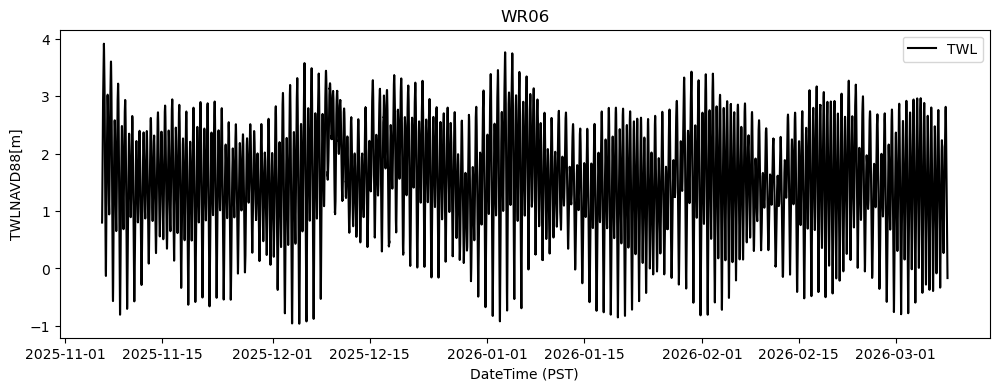

In [69]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(wr06_dt, wr06_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('WR06')
ax.legend();

### WR07

In [72]:
wr07_df.columns = wr07_df.columns.str.strip()
wr07_df = wr07_df[~wr07_df['Date'].str.contains('-', na=False)]

wr07_df['DateTime'] = pd.to_datetime(wr07_df['Date'] + ' ' + wr07_df['Time'])

wr07_df = wr07_df.reset_index(drop=True)

wr07_df["WR07 ABS PRESS [psi]"] = pd.to_numeric(wr07_df["Press"], errors='coerce')

wr07_df_trim = wr07_df.iloc[27:13910]
wr07_df_trim = wr07_df_trim.reset_index(drop=True)

wr07_df_trim["WR07 ABS PRESS [Pa]"] = wr07_df_trim["WR07 ABS PRESS [psi]"] * 6894.76
wr07_df_trim['DateTime'] = pd.to_datetime(wr07_df_trim['DateTime'])
wr07_df_trim['WR07 DATETIME [PST]'] = wr07_df_trim['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)
wr07_df_trim["WR07 TEMP [degC]"] = pd.to_numeric(wr07_df_trim["Temp"], errors='coerce')

salinity = 0.03 # PSU approx based on CTD data
wr07_df_trim["Rho[kg/m^3]"] = density(wr07_df_trim["WR07 TEMP [degC]"], salinity)
g = 9.81

wr07_itp_metp = itp_noaa_metdata(met_df_5min, wr07_df_trim["WR07 DATETIME [PST]"])
wr07_df_trim["WR07 MET PRESS [Pa]"] = wr07_itp_metp.values

wr07_df_trim["WR07 TWL [m]"] = (wr07_df_trim["WR07 ABS PRESS [Pa]"] - wr07_df_trim["WR07 MET PRESS [Pa]"]) / (wr07_df_trim["Rho[kg/m^3]"] * g)
wr07_df_trim["WR07 TWL [m]"] = np.where(wr07_df_trim["WR07 TWL [m]"] < 0, np.nan, wr07_df_trim["WR07 TWL [m]"])

wr07_df_trim["WR07 TWL NAVD88 [m]"] = wr07_df_trim["WR07 TWL [m]"] + 0.124 # meters
wr07_df_trim['WR07 OFFSET [m]'] = 0.124

wr07_dt = wr07_df_trim["WR07 DATETIME [PST]"]
wr07_twl = wr07_df_trim["WR07 TWL NAVD88 [m]"]

wr07_df_new = wr07_df_trim[['WR07 DATETIME [PST]', 'WR07 ABS PRESS [psi]', 'WR07 ABS PRESS [Pa]', 'WR07 TEMP [degC]', 'WR07 MET PRESS [Pa]', 'WR07 TWL [m]', 'WR07 OFFSET [m]', 'WR07 TWL NAVD88 [m]']]

wr07_df_new.head()

,WR07 DATETIME [PST],WR07 ABS PRESS [psi],WR07 ABS PRESS [Pa],WR07 TEMP [degC],WR07 MET PRESS [Pa],WR07 TWL [m],WR07 OFFSET [m],WR07 TWL NAVD88 [m]
0,2025-11-25 11:15:08,16.462,113501.53912,7.68,102236.666667,1.148397,0.124,1.272397
1,2025-11-25 11:20:08,16.515,113866.96140,7.67,102230.000000,1.186329,0.124,1.310329
2,2025-11-25 11:25:08,16.569,114239.27844,7.67,102223.333333,1.224965,0.124,1.348965
3,2025-11-25 11:30:08,16.626,114632.27976,7.67,102217.500000,1.265624,0.124,1.389624
4,2025-11-25 11:35:08,16.674,114963.22824,7.67,102212.500000,1.299872,0.124,1.423872


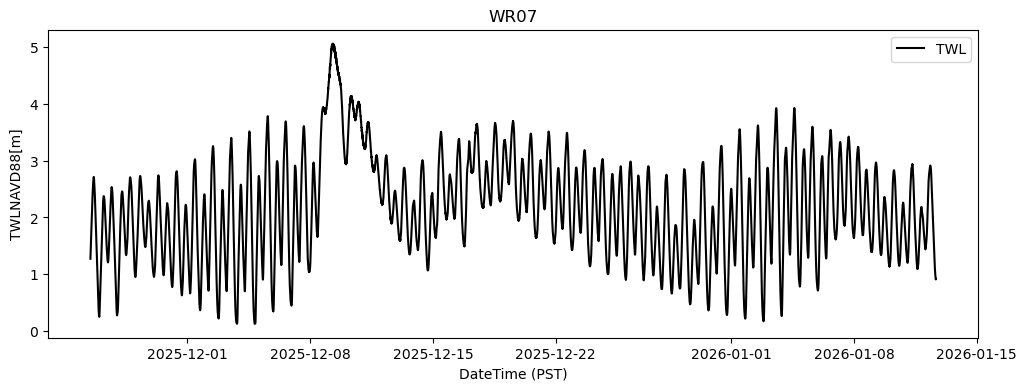

In [74]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(wr07_dt, wr07_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('WR07')
ax.legend();

### WR08

In [77]:
# CTD2004_WR08_012826.txt

wr08_df.columns = wr08_df.columns.str.strip()
wr08_df = wr08_df[~wr08_df['Date'].str.contains('-', na=False)]
wr08_df['DateTime'] = pd.to_datetime(wr08_df['Date'] + ' ' + wr08_df['Time'])
wr08_df = wr08_df.reset_index(drop=True)
wr08_df["WR08 ABS PRESS [psi]"] = pd.to_numeric(wr08_df["Press"], errors='coerce')
# wr06ctd_df = wr06ctd_df.iloc[27:13910] WHAT ABOUT THIS
wr08_df = wr08_df.reset_index(drop=True)
wr08_df["WR08 ABS PRESS [Pa]"] = wr08_df["WR08 ABS PRESS [psi]"] * 6894.76

wr08_df['DateTime'] = pd.to_datetime(wr08_df['DateTime'])
wr08_df['WR08 DATETIME [PST]'] = wr08_df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

wr08_df["WR08 TEMP [degC]"] = pd.to_numeric(wr08_df["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr08_df["Rho[kg/m^3]"] = density(wr08_df["WR08 TEMP [degC]"], salinity)

g = 9.81

wr08_itp_metp = itp_noaa_metdata(met_df_5min, wr08_df["DateTime"])
wr08_df["WR08 MET PRESS [Pa]"] = wr08_itp_metp.values

wr08_df["WR08 TWL [m]"] = (wr08_df["WR08 ABS PRESS [Pa]"] - wr08_df["WR08 MET PRESS [Pa]"]) / (wr08_df["Rho[kg/m^3]"] * g)
wr08_df["WR08 TWL [m]"] = np.where(wr08_df["WR08 TWL [m]"] < 0, np.nan, wr08_df["WR08 TWL [m]"])

wr08_df_trim = wr08_df.iloc[46:18496]
wr08_dt = wr08_df_trim["WR08 DATETIME [PST]"]
wr08_twl = wr08_df_trim["WR08 TWL [m]"]

wr08_df_new = wr08_df_trim[['WR08 DATETIME [PST]', 'WR08 ABS PRESS [psi]', 'WR08 ABS PRESS [Pa]', 'WR08 TEMP [degC]', 'WR08 MET PRESS [Pa]', 'WR08 TWL [m]']]

wr08_df_new.head()

,WR08 DATETIME [PST],WR08 ABS PRESS [psi],WR08 ABS PRESS [Pa],WR08 TEMP [degC],WR08 MET PRESS [Pa],WR08 TWL [m]
46,2025-11-25 12:50:08,16.921,116666.23396,7.39,101825.000000,1.513003
47,2025-11-25 12:55:08,16.982,117086.81432,7.38,101828.333333,1.555539
48,2025-11-25 13:00:08,17.038,117472.92088,7.37,101835.000000,1.594220
49,2025-11-25 13:05:08,17.084,117790.07984,7.38,101845.000000,1.625535
50,2025-11-25 13:10:08,17.126,118079.65976,7.39,101855.000000,1.654038


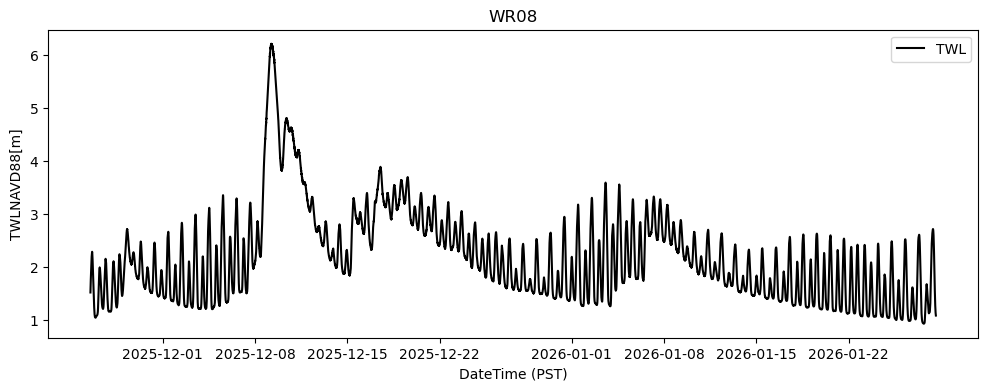

In [79]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(wr08_dt, wr08_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('WR08')
ax.legend();

## Willapa River Timestack

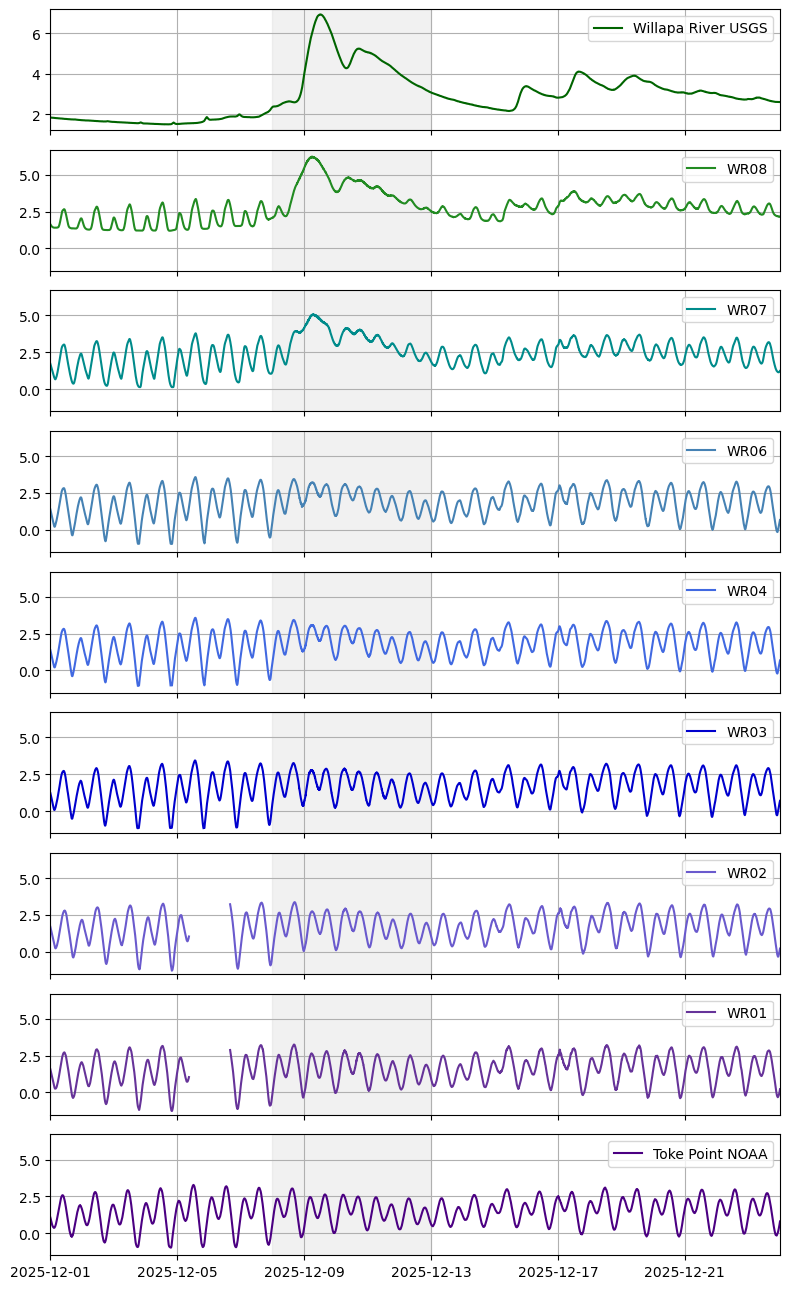

In [82]:
# whole range
# fig, ax = plt.subplots(9, 1, figsize=(12, 20), sharex=True)
# plot_start = pd.to_datetime('2025-11-01')
# plot_end = pd.to_datetime('2026-03-09')

# zoom range
fig, ax = plt.subplots(9, 1, figsize=(8, 13), sharex=True)
plot_start = pd.to_datetime('2025-12-01')
plot_end = pd.to_datetime('2025-12-24')

# Convert to datetime and create masks for filtering
usgs_dt = pd.to_datetime(usgs_dt, errors='coerce')
usgs_mask = (usgs_dt >= plot_start) & (usgs_dt <= plot_end)

wr08_dt = pd.to_datetime(wr08_dt, errors='coerce')
wr08_mask = (wr08_dt >= plot_start) & (wr08_dt <= plot_end)

wr07_dt = pd.to_datetime(wr07_dt, errors='coerce')
wr07_mask = (wr07_dt >= plot_start) & (wr07_dt <= plot_end)

wr06_dt = pd.to_datetime(wr06_dt, errors='coerce')
wr06_mask = (wr06_dt >= plot_start) & (wr06_dt <= plot_end)

wr04_dt = pd.to_datetime(wr04_dt, errors='coerce')
wr04_mask = (wr04_dt >= plot_start) & (wr04_dt <= plot_end)

wr03_dt = pd.to_datetime(wr03_dt, errors='coerce')
wr03_mask = (wr03_dt >= plot_start) & (wr03_dt <= plot_end)

wr02_dt = pd.to_datetime(wr02_dt, errors='coerce')
wr02_mask = (wr02_dt >= plot_start) & (wr02_dt <= plot_end)

wr01_dt = pd.to_datetime(wr01_dt, errors='coerce')
wr01_mask = (wr01_dt >= plot_start) & (wr01_dt <= plot_end)

TP_dt = pd.to_datetime(TP_dt, errors='coerce')
TP_mask = (TP_dt >= plot_start) & (TP_dt <= plot_end)

# Plot each dataset on separate panels with color gradient
ax[0].plot(usgs_dt[usgs_mask], usgs_twl[usgs_mask], color='darkgreen', label='Willapa River USGS')
ax[0].legend(loc='upper right')
ax[0].grid()

ax[1].plot(wr08_dt[wr08_mask], wr08_twl[wr08_mask], color='forestgreen', label='WR08')
ax[1].legend(loc='upper right')
ax[1].grid()
ax[1].set_ylim([-1.5, 6.7])

ax[2].plot(wr07_dt[wr07_mask], wr07_twl[wr07_mask], color='darkcyan', label='WR07')
ax[2].legend(loc='upper right')
ax[2].grid()
ax[2].set_ylim([-1.5, 6.7])

ax[3].plot(wr06_dt[wr06_mask], wr06_twl[wr06_mask], color='steelblue', label='WR06')
ax[3].legend(loc='upper right')
ax[3].grid()
ax[3].set_ylim([-1.5, 6.7])

ax[4].plot(wr04_dt[wr04_mask], wr04_twl[wr04_mask], color='royalblue', label='WR04')
# ax[4].set_ylabel('Water Level [m] NAVD88')  # Only y-axis label
ax[4].legend(loc='upper right')
ax[4].grid()
ax[4].set_ylim([-1.5, 6.7])

ax[5].plot(wr03_dt[wr03_mask], wr03_twl[wr03_mask], color='mediumblue', label='WR03')
ax[5].legend(loc='upper right')
ax[5].grid()
ax[5].set_ylim([-1.5, 6.7])

ax[6].plot(wr02_dt[wr02_mask], wr02_twl[wr02_mask], color='slateblue', label='WR02')
ax[6].legend(loc='upper right')
ax[6].grid()
ax[6].set_ylim([-1.5, 6.7])

ax[7].plot(wr01_dt[wr01_mask], wr01_twl[wr01_mask], color='rebeccapurple', label='WR01')
ax[7].legend(loc='upper right')
ax[7].grid()
ax[7].set_ylim([-1.5, 6.7])

ax[8].plot(TP_dt[TP_mask], TP_twl[TP_mask], color='indigo', label='Toke Point NOAA')
# ax[8].set_xlabel('DateTime (PST)')
ax[8].legend(loc='upper right')
ax[8].grid()
ax[8].set_ylim([-1.5, 6.7])

# Set x-axis limits for all panels
for i in ax:
    i.set_xlim([plot_start, plot_end])

# fig.suptitle("Along-channel evolution of compound flooding")

shade_start = pd.Timestamp('2025-12-08')
shade_end = pd.Timestamp('2025-12-13')

for ax in ax:
    ax.axvspan(shade_start, shade_end, alpha=0.3, color='lightgrey', zorder=0)

fig.tight_layout()
plt.show()

## **South Fork**

### SF01

In [86]:
sf01_d4_df_trim = sf01_d4_df.iloc[318:19388].copy()
sf01_d4_df_trim['Date/time'] = pd.to_datetime(sf01_d4_df_trim['Date/time'])

In [88]:
sf01_d4_df_trim['SF01 ABS PRESS [ftH2O]'] = sf01_d4_df_trim['Pressure[ftH2O]'].interpolate(method='linear')
sf01_d4_df_trim['SF01 ABS PRESS [cmH2O]'] = sf01_d4_df_trim['SF01 ABS PRESS [ftH2O]'] * 30.48

sf01_d4_df_trim['SF01 DATETIME [PST]'] = sf01_d4_df_trim['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)
sf01_d4_df_trim["SF01 TEMP [degC]"] = sf01_d4_df_trim["Temperature[°C]"]

g = 9.81 # m/s^2
salinity = 0.5 # PSU approx based on CTD data
sf01_d4_df_trim["Rho[kg/m^3]"] = density(sf01_d4_df_trim["SF01 TEMP [degC]"], salinity)

sf01_d4_absp_Pa = ftH2O_to_Pa(sf01_d4_df_trim["Pressure[ftH2O]"], sf01_d4_df_trim["SF01 TEMP [degC]"], salinity)
sf01_d4_df_trim["SF01 ABS PRESS [Pa]"] = sf01_d4_absp_Pa

sf01_d4_itp_metp = itp_noaa_metdata(met_df_5min, sf01_d4_df_trim["SF01 DATETIME [PST]"])
sf01_d4_df_trim["SF01 MET PRESS [Pa]"] = sf01_d4_itp_metp.values

sf01_d4_df_trim["SF01 TWL [m]"] = (sf01_d4_df_trim["SF01 ABS PRESS [Pa]"] - sf01_d4_df_trim["SF01 MET PRESS [Pa]"]) / (sf01_d4_df_trim["Rho[kg/m^3]"] * g)
sf01_d4_df_trim["SF01 TWL [m]"] = np.where(sf01_d4_df_trim["SF01 TWL [m]"] < 0, np.nan, sf01_d4_df_trim["SF01 TWL [m]"])

sf01_d4_df_trim["SF01 TWL NAVD88 [m]"] = sf01_d4_df_trim["SF01 TWL [m]"] - 0.652
sf01_d4_df_trim['SF01 OFFSET [m]'] = - 0.652

sf01_d4_dt = sf01_d4_df_trim["SF01 DATETIME [PST]"]
sf01_d4_twl = sf01_d4_df_trim["SF01 TWL NAVD88 [m]"]

sf01_d4_df_new = sf01_d4_df_trim[['SF01 DATETIME [PST]', 'SF01 ABS PRESS [cmH2O]', 'SF01 ABS PRESS [Pa]', 'SF01 TEMP [degC]', 'SF01 MET PRESS [Pa]', 'SF01 TWL [m]', 'SF01 OFFSET [m]', 'SF01 TWL NAVD88 [m]']]

sf01_d4_df_new.head()

,SF01 DATETIME [PST],SF01 ABS PRESS [cmH2O],SF01 ABS PRESS [Pa],SF01 TEMP [degC],SF01 MET PRESS [Pa],SF01 TWL [m],SF01 OFFSET [m],SF01 TWL NAVD88 [m]
318,2025-11-07 08:30:00,1231.483440,120821.111110,10.397,102150.000000,1.903075,-0.652,1.251075
319,2025-11-07 08:35:00,1234.575026,121124.167453,10.420,102153.333333,1.933629,-0.652,1.281629
320,2025-11-07 08:40:00,1237.433441,121404.606517,10.420,102156.666667,1.961873,-0.652,1.309873
321,2025-11-07 08:45:00,1240.408289,121696.468882,10.420,102160.000000,1.991282,-0.652,1.339282
322,2025-11-07 08:50:00,1243.791569,122028.322661,10.427,102163.333333,2.024768,-0.652,1.372768


In [90]:
sf01_d5_df_trim = sf01_d5_df.iloc[10:15820].copy()
sf01_d5_df_trim.head() # 15824 long
sf01_d5_df_trim['Date/time'] = pd.to_datetime(sf01_d5_df_trim['Date/time'])

In [92]:
## Convert to TWL NAVD88

sf01_d5_df_trim['SF01 ABS PRESS [cmH2O]'] = sf01_d5_df_trim['Pressure[cmH2O]'].interpolate(method='linear')

sf01_d5_df_trim['Date/time'] = pd.to_datetime(sf01_d5_df_trim['Date/time'])
sf01_d5_df_trim['SF01 DATETIME [PST]'] = sf01_d5_df_trim['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)
sf01_d5_df_trim["SF01 TEMP [degC]"] = sf01_d5_df_trim["Temperature[°C]"]

g = 9.81 # m/s^2
salinity = 0.5 # PSU approx based on CTD data
sf01_d5_df_trim["Rho[kg/m^3]"] = density(sf01_d5_df_trim["SF01 TEMP [degC]"], salinity)

sf01_d5_absp_Pa = cmH2O_to_Pa(sf01_d5_df_trim["SF01 ABS PRESS [cmH2O]"], sf01_d5_df_trim["SF01 TEMP [degC]"], salinity)
sf01_d5_df_trim["SF01 ABS PRESS [Pa]"] = sf01_d5_absp_Pa

sf01_d5_itp_metp = itp_noaa_metdata(met_df_5min, sf01_d5_df_trim["SF01 DATETIME [PST]"])
sf01_d5_df_trim["SF01 MET PRESS [Pa]"] = sf01_d5_itp_metp.values

sf01_d5_df_trim["SF01 TWL [m]"] = (sf01_d5_df_trim["SF01 ABS PRESS [Pa]"] - sf01_d5_df_trim["SF01 MET PRESS [Pa]"]) / (sf01_d5_df_trim["Rho[kg/m^3]"] * g)
sf01_d5_df_trim["SF01 TWL [m]"] = np.where(sf01_d5_df_trim["SF01 TWL [m]"] < 0, np.nan, sf01_d5_df_trim["SF01 TWL [m]"])

sf01_d5_df_trim["SF01 TWL NAVD88 [m]"] = sf01_d5_df_trim["SF01 TWL [m]"] - 0.652
sf01_d5_df_trim["SF01 OFFSET [m]"] = - 0.652

sf01_d5_dt = sf01_d5_df_trim["SF01 DATETIME [PST]"]
sf01_d5_twl = sf01_d5_df_trim["SF01 TWL NAVD88 [m]"]


sf01_d5_df_new = sf01_d5_df_trim[['SF01 DATETIME [PST]', 'SF01 ABS PRESS [cmH2O]', 'SF01 ABS PRESS [Pa]', 'SF01 TEMP [degC]', 'SF01 MET PRESS [Pa]', 'SF01 TWL [m]', 'SF01 OFFSET [m]', 'SF01 TWL NAVD88 [m]']]

sf01_d5_df_new.head()

,SF01 DATETIME [PST],SF01 ABS PRESS [cmH2O],SF01 ABS PRESS [Pa],SF01 TEMP [degC],SF01 MET PRESS [Pa],SF01 TWL [m],SF01 OFFSET [m],SF01 TWL NAVD88 [m]
10,2026-01-12 14:42:29,1190.592,116817.581750,9.583,102737.500000,1.435027,-0.652,0.783027
11,2026-01-12 14:47:29,1188.900,116651.720668,9.567,102732.500000,1.418630,-0.652,0.766630
12,2026-01-12 14:52:29,1187.208,116485.553065,9.583,102727.500000,1.402206,-0.652,0.750206
13,2026-01-12 14:57:29,1185.692,116336.740356,9.590,102722.500000,1.387549,-0.652,0.735549
14,2026-01-12 15:02:29,1184.000,116170.563312,9.607,102721.666667,1.370700,-0.652,0.718700


**Combine all data for SF01**

In [95]:
sf01_df = pd.concat([sf01_d4_df_new, sf01_d5_df_new], ignore_index=True)

sf01_dt = sf01_df["SF01 DATETIME [PST]"]
sf01_twl = sf01_df["SF01 TWL NAVD88 [m]"]

sf01_df.head()

,SF01 DATETIME [PST],SF01 ABS PRESS [cmH2O],SF01 ABS PRESS [Pa],SF01 TEMP [degC],SF01 MET PRESS [Pa],SF01 TWL [m],SF01 OFFSET [m],SF01 TWL NAVD88 [m]
0,2025-11-07 08:30:00,1231.483440,120821.111110,10.397,102150.000000,1.903075,-0.652,1.251075
1,2025-11-07 08:35:00,1234.575026,121124.167453,10.420,102153.333333,1.933629,-0.652,1.281629
2,2025-11-07 08:40:00,1237.433441,121404.606517,10.420,102156.666667,1.961873,-0.652,1.309873
3,2025-11-07 08:45:00,1240.408289,121696.468882,10.420,102160.000000,1.991282,-0.652,1.339282
4,2025-11-07 08:50:00,1243.791569,122028.322661,10.427,102163.333333,2.024768,-0.652,1.372768


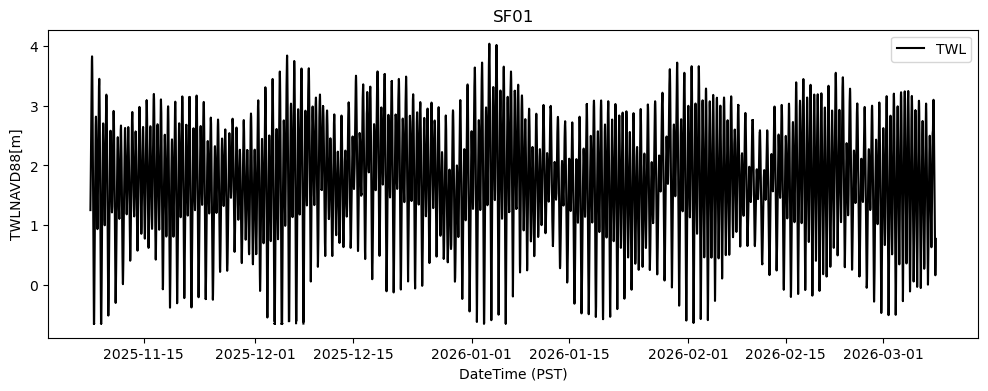

In [97]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(sf01_dt, sf01_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('SF01')
ax.legend();

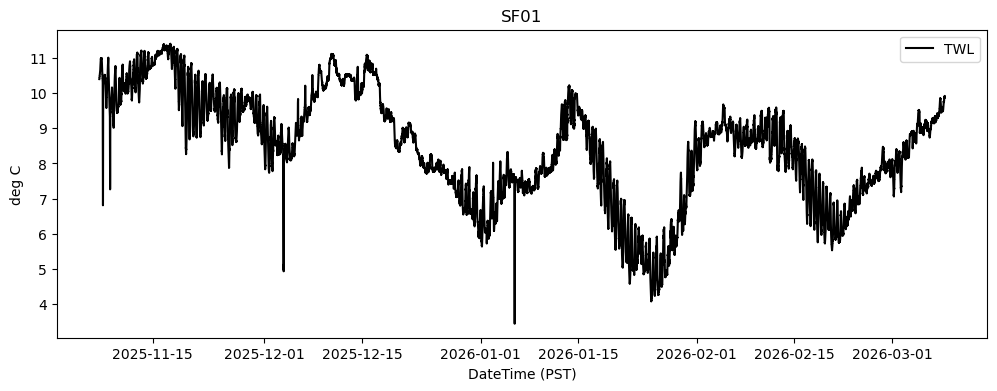

In [98]:
# Convert datetime to numeric

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(sf01_dt, sf01_df['SF01 TEMP [degC]'], label='TWL', color='black')
ax.set_ylabel('deg C')
ax.set_xlabel('DateTime (PST)')
ax.set_title('SF01')
ax.legend();

### SF02

In [102]:
sf02_d4_df_trim = sf02_d4_df.iloc[322:19383].copy() # 19389 long
sf02_d4_df_trim['Date/time'] = pd.to_datetime(sf02_d4_df_trim['Date/time'])

In [104]:
sf02_d4_df_trim['SF02 ABS PRESS [ftH2O]'] = sf02_d4_df_trim['Pressure[ftH2O]'].interpolate(method='linear')

sf02_d4_df_trim['SF02 DATETIME [PST]'] = sf02_d4_df_trim['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)
sf02_d4_df_trim["SF02 TEMP [degC]"] = sf02_d4_df_trim["Temperature[°C]"]

g = 9.81 # m/s^2
salinity = 0.5 # PSU approx based on CTD data
sf02_d4_df_trim["Rho[kg/m^3]"] = density(sf02_d4_df_trim["SF02 TEMP [degC]"], salinity)

sf02_d4_absp_Pa = ftH2O_to_Pa(sf02_d4_df_trim["SF02 ABS PRESS [ftH2O]"], sf02_d4_df_trim["SF02 TEMP [degC]"], salinity)
sf02_d4_df_trim["SF02 ABS PRESS [Pa]"] = sf02_d4_absp_Pa

sf02_d4_itp_metp = itp_noaa_metdata(met_df_5min, sf02_d4_df_trim["SF02 DATETIME [PST]"])
sf02_d4_df_trim["SF02 MET PRESS [Pa]"] = sf02_d4_itp_metp.values

sf02_d4_df_trim["SF02 TWL [m]"] = (sf02_d4_df_trim["SF02 ABS PRESS [Pa]"] - sf02_d4_df_trim["SF02 MET PRESS [Pa]"]) / (sf02_d4_df_trim["Rho[kg/m^3]"] * g)
sf02_d4_df_trim["SF02 TWL [m]"] = np.where(sf02_d4_df_trim["SF02 TWL [m]"] < 0, np.nan, sf02_d4_df_trim["SF02 TWL [m]"])

sf02_d4_df_trim["SF02 TWL NAVD88 [m]"] = sf02_d4_df_trim["SF02 TWL [m]"] - 0.949 # used to be - 1.006
sf02_d4_df_trim["SF02 OFFSET [m]"]= - 0.949 # used to be - 1.006

sf02_d4_dt = sf02_d4_df_trim["SF02 DATETIME [PST]"]
sf02_d4_twl = sf02_d4_df_trim["SF02 TWL NAVD88 [m]"]

sf02_d4_df_new = sf02_d4_df_trim[['SF02 DATETIME [PST]', 'SF02 ABS PRESS [ftH2O]', 'SF02 ABS PRESS [Pa]', 'SF02 TEMP [degC]', 'SF02 MET PRESS [Pa]', 'SF02 TWL [m]', 'SF02 OFFSET [m]', 'SF02 TWL NAVD88 [m]']]

sf02_d4_df_new.head()

,SF02 DATETIME [PST],SF02 ABS PRESS [ftH2O],SF02 ABS PRESS [Pa],SF02 TEMP [degC],SF02 MET PRESS [Pa],SF02 TWL [m],SF02 OFFSET [m],SF02 TWL NAVD88 [m]
322,2025-11-07 08:50:00,40.69581,121701.634521,9.950,102163.333333,1.991384,-0.949,1.042384
323,2025-11-07 08:55:00,40.81638,122062.201520,9.950,102166.666667,2.027794,-0.949,1.078794
324,2025-11-07 09:00:00,40.93695,122422.949701,9.933,102170.000000,2.064220,-0.949,1.115220
325,2025-11-07 09:05:00,41.02499,122686.128724,9.943,102176.666667,2.090366,-0.949,1.141366
326,2025-11-07 09:10:00,41.13790,123023.788545,9.943,102183.333333,2.124101,-0.949,1.175101


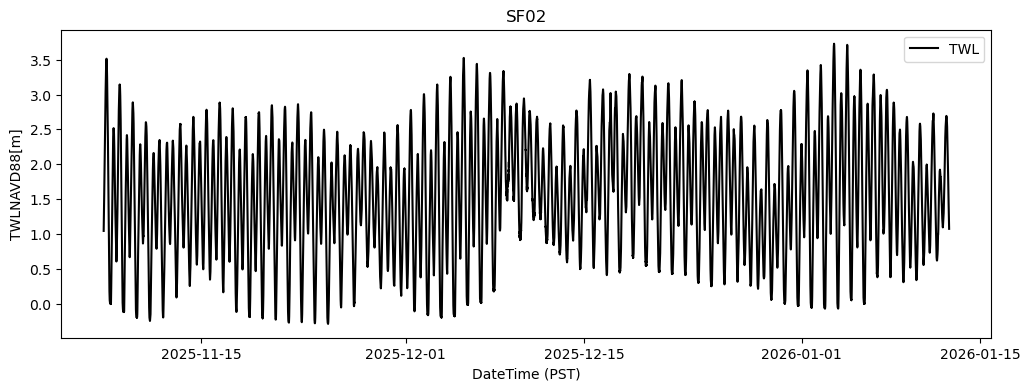

In [106]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(sf02_d4_dt, sf02_d4_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('SF02')
ax.legend();

In [107]:
# import matplotlib.dates as mdates

# fig, ax = plt.subplots(figsize=(12,6))
# ax.plot(sf01_dt, sf01_twl, label='SF01', color='blue', linewidth=2.5)
# ax.plot(sf02_d4_dt, sf02_d4_twl, label='SF02', color='red', linewidth=2.5, alpha=0.7)
# ax.set_ylabel('TWLNAVD88[m]')
# ax.set_xlabel('DateTime (PST)')
# ax.set_title('SF01 to SF02 comparison')
# ax.set_xlim(pd.Timestamp('2025-12-01'), pd.Timestamp('2025-12-31'))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
# ax.legend();

### SF03

In [111]:
sf03_d5_df.head() # 29750 long
sf03_d5_df_trim = sf03_d5_df[:].copy()
sf03_d5_df_trim['SF03 DATETIME [PST]'] = pd.to_datetime(sf03_d5_df_trim['Date Time, GMT-08:00'], format='%m/%d/%y %I:%M:%S %p')

sf03_d4_df_trim = sf03_d5_df_trim[(sf03_d5_df_trim['SF03 DATETIME [PST]'] >= '2025-11-25 17:15') & 
                                    (sf03_d5_df_trim['SF03 DATETIME [PST]'] < '2026-01-12 11:35')]

sf03_d5_df_trim = sf03_d5_df_trim[(sf03_d5_df_trim['SF03 DATETIME [PST]'] >= '2026-01-12 11:35') & 
                                    (sf03_d5_df_trim['SF03 DATETIME [PST]'] <= '2026-03-09 17:09')].iloc[9:15800]

# combine
sf03_combined_df_trim = pd.concat([sf03_d4_df_trim, sf03_d5_df_trim]).sort_values('SF03 DATETIME [PST]').reset_index(drop=True)

In [113]:
## Convert to TWL (relative)
sf03_combined_df_trim['SF03 ABS PRESS [psi]'] = sf03_combined_df_trim['Abs Pres, psi (LGR S/N: 1289199, SEN S/N: 1289199)'].interpolate(method='linear')

g = 9.81 # m/s^2
PSI_to_Pa = 6894.76  # 1 PSI = 6894.76 Pa
salinity = 0 # very very upstream
temperature = 7.719 # deg C based on mean from SF01

sf03_combined_df_trim["SF03 ABS PRESS [Pa]"] = sf03_combined_df_trim['SF03 ABS PRESS [psi]'] * PSI_to_Pa
sf03_combined_df_trim["Rho[kg/m^3]"] = density(temperature, salinity)

sf03_itp_metp = itp_noaa_metdata(met_df_5min, sf03_combined_df_trim["SF03 DATETIME [PST]"])
sf03_combined_df_trim["SF03 MET PRESS [Pa]"] = sf03_itp_metp.values

sf03_combined_df_trim["SF03 TWL [m]"] = (sf03_combined_df_trim["SF03 ABS PRESS [Pa]"] - sf03_combined_df_trim["SF03 MET PRESS [Pa]"]) / (sf03_combined_df_trim["Rho[kg/m^3]"] * g)
sf03_combined_df_trim["SF03 TWL [m]"] = np.where(sf03_combined_df_trim["SF03 TWL [m]"] < 0, np.nan, sf03_combined_df_trim["SF03 TWL [m]"])

sf03_dt = sf03_combined_df_trim["SF03 DATETIME [PST]"]
sf03_twl = sf03_combined_df_trim["SF03 TWL [m]"] # just relative distance

sf03_combined_df_trim['SF03 approx TEMP [degC]'] = 7.719

sf03_df_new = sf03_combined_df_trim[['SF03 DATETIME [PST]', 'SF03 ABS PRESS [psi]', 'SF03 ABS PRESS [Pa]', 'SF03 approx TEMP [degC]', 'SF03 MET PRESS [Pa]', 'SF03 TWL [m]']]

sf03_df_new.head()

,SF03 DATETIME [PST],SF03 ABS PRESS [psi],SF03 ABS PRESS [Pa],SF03 approx TEMP [degC],SF03 MET PRESS [Pa],SF03 TWL [m]
0,2025-11-25 17:15:00,15.0686,103894.380536,7.719,101830.000000,0.210459
1,2025-11-25 17:20:00,15.0732,103926.096432,7.719,101826.666667,0.214032
2,2025-11-25 17:25:00,15.0802,103974.359752,7.719,101823.333333,0.219292
3,2025-11-25 17:30:00,15.0802,103974.359752,7.719,101820.000000,0.219632
4,2025-11-25 17:35:00,15.0802,103974.359752,7.719,101818.333333,0.219802


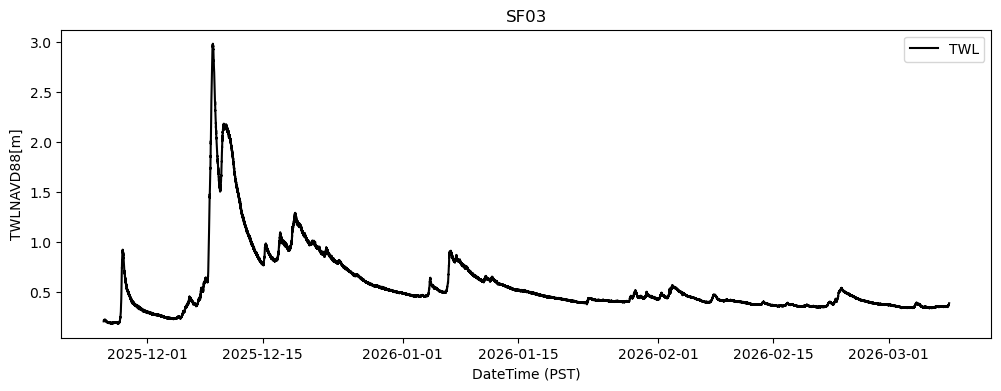

In [115]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(sf03_dt, sf03_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('SF03')
ax.legend();

## **Skidmore Slough**

In [118]:
## for temp interpolation, use SF01 data

y = sf01_df['SF01 TEMP [degC]']
smoothed_sf01_temp = savgol_filter(y, window_length=100, polyorder=3)

## interpolate to each dataset

def interpolate_sf01_temp(target_datetime):
    target_numeric = pd.to_datetime(target_datetime, format='%m/%d/%y %I:%M:%S %p').astype(np.int64)
    sf01_numeric = sf01_df['SF01 DATETIME [PST]'].astype(np.int64)
    
    itp_temp = np.interp(target_numeric, sf01_numeric, smoothed_sf01_temp)
    return itp_temp

ss01_itp_temp = interpolate_sf01_temp(ss01_df['Date Time, GMT+00:00'])
ss02_D4_itp_temp = interpolate_sf01_temp(ss02_D4_df['Date Time, GMT+00:00'])
ss02_D5_itp_temp = interpolate_sf01_temp(ss02_D5_df['Date Time, GMT+00:00'])
ss03_D4_itp_temp = interpolate_sf01_temp(ss03_D4_df['Date Time, GMT+00:00'])
ss03_D5_itp_temp = interpolate_sf01_temp(ss03_D5_df['Date Time, GMT+00:00'])

### SS01 (downstream)

In [121]:
ss01_df = pd.read_csv(ss01_file, skiprows=1, usecols=range(3))

ss01_df['SS01 DATETIME [PST]'] = (
    pd.to_datetime(ss01_df['Date Time, GMT+00:00'], format='%m/%d/%y %I:%M:%S %p')
    .dt.tz_localize('UTC')
    .dt.tz_convert('Etc/GMT+8')
    .dt.tz_localize(None))

g = 9.81  # m/s^2
salinity = 0.5  # PSU approx
navd88_offset = 0.368  # m
temperature_assumed = ss01_itp_temp  # deg C

ss01_itp_metp = itp_noaa_metdata(met_df_5min, ss01_df['SS01 DATETIME [PST]'])
ss01_df['SS01 MET PRESS [Pa]'] = ss01_itp_metp.values
ss01_df['SS01 TWL [m]'] = (
    (ss01_df['Abs Pres, Pa (LGR S/N: 1126515, SEN S/N: 1126515)'] - ss01_df['SS01 MET PRESS [Pa]'])
    / (density(temperature_assumed, salinity) * g)
)
ss01_df['SS01 TWL [m]'] = np.where(ss01_df['SS01 TWL [m]'] < 0, np.nan, ss01_df['SS01 TWL [m]'])
ss01_df['SS01 TWL NAVD88 [m]'] = ss01_df['SS01 TWL [m]'] + navd88_offset

ss01_df['SS01 OFFSET [m]'] = navd88_offset
ss01_df['SS01 approx TEMP [degC]'] = ss01_itp_temp

ss01_df_trim = ss01_df[13:34855].copy()
ss01_dt = ss01_df_trim['SS01 DATETIME [PST]']
ss01_twl = ss01_df_trim['SS01 TWL NAVD88 [m]']
ss01_df_trim['SS01 ABS PRESS [Pa]'] = ss01_df_trim['Abs Pres, Pa (LGR S/N: 1126515, SEN S/N: 1126515)']

ss01_df_new = ss01_df_trim[['SS01 DATETIME [PST]', 'SS01 ABS PRESS [Pa]', 'SS01 approx TEMP [degC]', 'SS01 MET PRESS [Pa]', 'SS01 TWL [m]', 'SS01 TWL NAVD88 [m]']]

ss01_df_new.head()

,SS01 DATETIME [PST],SS01 ABS PRESS [Pa],SS01 approx TEMP [degC],SS01 MET PRESS [Pa],SS01 TWL [m],SS01 TWL NAVD88 [m]
13,2025-11-08 10:05:00,109806.0,10.188013,102061.666667,0.789335,1.157335
14,2025-11-08 10:10:00,110160.0,10.132839,102053.333333,0.826262,1.194262
15,2025-11-08 10:15:00,110616.0,10.078512,102045.000000,0.873584,1.241584
16,2025-11-08 10:20:00,111005.0,10.024911,102036.666667,0.914077,1.282077
17,2025-11-08 10:25:00,111462.0,9.972309,102028.333333,0.961501,1.329501


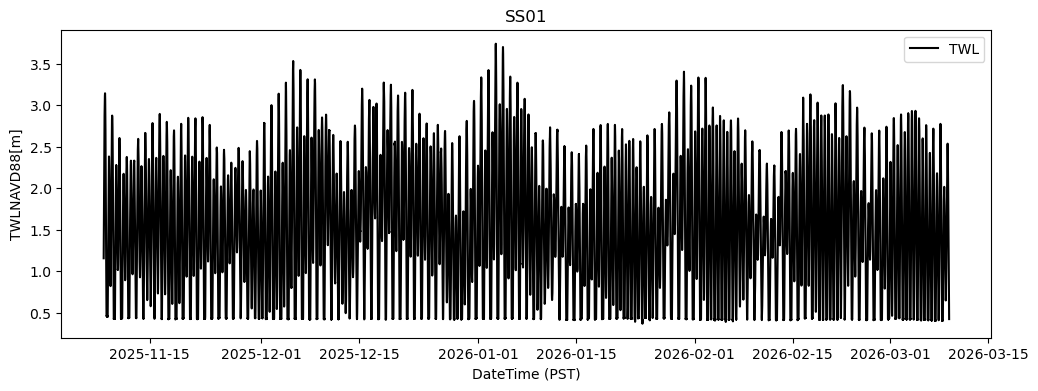

In [123]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(ss01_dt, ss01_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('SS01')
ax.legend();

### SS02 (upstream)

In [126]:
ss02_D4_df = pd.read_csv(ss02_D4_file, skiprows=1, usecols=range(3))
ss02_D5_df = pd.read_csv(ss02_D5_file, skiprows=1, usecols=range(3))

# D4 deployment
ss02_D4_df['SS02 DATETIME [PST]'] = (
    pd.to_datetime(ss02_D4_df['Date Time, GMT+00:00'], format='%m/%d/%y %I:%M:%S %p')
    .dt.tz_localize('UTC')
    .dt.tz_convert('Etc/GMT+8')
    .dt.tz_localize(None))
salinity = 0.5  # PSU
navd88_offset = 0.504  # m
D4_temperature_assumed = ss02_D4_itp_temp
D5_temperature_assumed = ss02_D5_itp_temp
ss02_D4_itp_metp = itp_noaa_metdata(met_df_5min, ss02_D4_df['SS02 DATETIME [PST]'])
ss02_D4_df['SS02 MET PRESS [Pa]'] = ss02_D4_itp_metp.values
ss02_D4_df['SS02 ABS PRESS [Pa]'] = ss02_D4_df['Abs Pres, Pa (LGR S/N: 1126509, SEN S/N: 1126509)']
ss02_D4_df['SS02 TWL [m]'] = (
    (ss02_D4_df['SS02 ABS PRESS [Pa]'] - ss02_D4_df['SS02 MET PRESS [Pa]'])
    / (density(D4_temperature_assumed, salinity) * g)
)
ss02_D4_df['SS02 TWL [m]'] = np.where(ss02_D4_df['SS02 TWL [m]'] < 0, np.nan, ss02_D4_df['SS02 TWL [m]'])
ss02_D4_df['SS02 TWL NAVD88 [m]'] = ss02_D4_df['SS02 TWL [m]'] + navd88_offset
ss02_D4_df['SS02 approx TEMP [degC]'] = ss02_D4_itp_temp
ss02_D4_df_trim = ss02_D4_df[25:].copy()

# D5 deployment
ss02_D5_df['SS02 DATETIME [PST]'] = (
    pd.to_datetime(ss02_D5_df['Date Time, GMT+00:00'], format='%m/%d/%y %I:%M:%S %p')
    .dt.tz_localize('UTC')
    .dt.tz_convert('Etc/GMT+8')
    .dt.tz_localize(None)
)
navd88_offset = 0.521  # m
ss02_D5_itp_metp = itp_noaa_metdata(met_df_5min, ss02_D5_df['SS02 DATETIME [PST]'])
ss02_D5_df['SS02 MET PRESS [Pa]'] = ss02_D5_itp_metp.values
ss02_D5_df['SS02 ABS PRESS [Pa]'] = ss02_D5_df['Abs Pres, Pa (LGR S/N: 1126509, SEN S/N: 1126509)']
ss02_D5_df['SS02 TWL [m]'] = (
    (ss02_D5_df['SS02 ABS PRESS [Pa]'] - ss02_D5_df['SS02 MET PRESS [Pa]'])
    / (density(D5_temperature_assumed, salinity) * g)
)
ss02_D5_df['SS02 TWL [m]'] = np.where(ss02_D5_df['SS02 TWL [m]'] < 0, np.nan, ss02_D5_df['SS02 TWL [m]'])
ss02_D5_df['SS02 TWL NAVD88 [m]'] = ss02_D5_df['SS02 TWL [m]'] + navd88_offset
ss02_D5_df['SS02 approx TEMP [degC]'] = ss02_D5_itp_temp
ss02_D5_df_trim = ss02_D5_df[6:16108].copy()

# Combine
ss02_df_trim = pd.concat([ss02_D4_df_trim, ss02_D5_df_trim]).sort_values('SS02 DATETIME [PST]').reset_index(drop=True)
ss02_dt = ss02_df_trim['SS02 DATETIME [PST]']
ss02_twl = ss02_df_trim['SS02 TWL NAVD88 [m]']
ss02_df_new = ss02_df_trim[['SS02 DATETIME [PST]', 'SS02 ABS PRESS [Pa]', 'SS02 approx TEMP [degC]', 'SS02 MET PRESS [Pa]', 'SS02 TWL [m]', 'SS02 TWL NAVD88 [m]']]
ss02_df_new.head()

,SS02 DATETIME [PST],SS02 ABS PRESS [Pa],SS02 approx TEMP [degC],SS02 MET PRESS [Pa],SS02 TWL [m],SS02 TWL NAVD88 [m]
0,2025-11-08 11:05:00,106520.0,9.589186,101998.333333,0.460844,0.964844
1,2025-11-08 11:10:00,106553.0,9.546670,101996.666667,0.464375,0.968375
2,2025-11-08 11:15:00,106553.0,9.505555,101995.000000,0.464543,0.968543
3,2025-11-08 11:20:00,106569.0,9.466154,101993.333333,0.466342,0.970342
4,2025-11-08 11:25:00,106602.0,9.428214,101991.666667,0.469874,0.973874


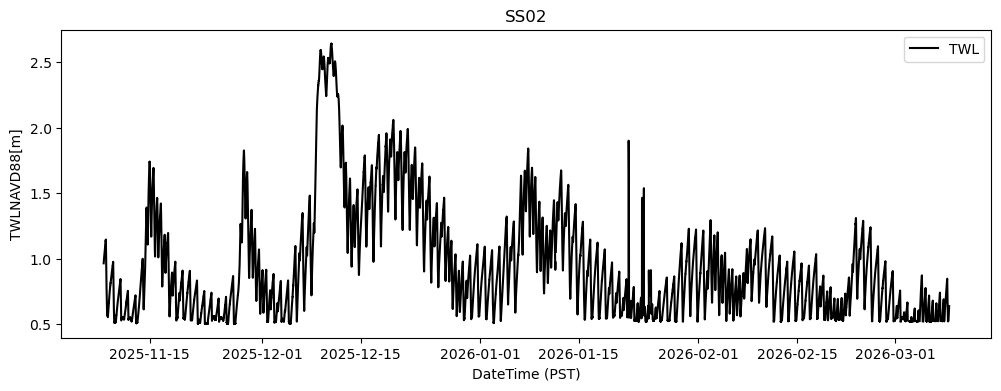

In [128]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(ss02_dt, ss02_twl, label='TWL', color='black') 
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('SS02')
ax.legend();

### SS03 (middle)

In [131]:
ss03_D4_df = pd.read_csv(ss03_D4_file, skiprows=1, usecols=range(3))
ss03_D5_df = pd.read_csv(ss03_D5_file, skiprows=1, usecols=range(3))

# D4 deployment
ss03_D4_df['SS03 DATETIME [PST]'] = (
    pd.to_datetime(ss03_D4_df['Date Time, GMT+00:00'], format='%m/%d/%y %I:%M:%S %p')
    .dt.tz_localize('UTC')
    .dt.tz_convert('Etc/GMT+8')
    .dt.tz_localize(None)
)
salinity = 0.5  # PSU
navd88_offset = 0.192  # m
D4_temperature_assumed = ss03_D4_itp_temp
D5_temperature_assumed = ss03_D5_itp_temp
ss03_D4_itp_metp = itp_noaa_metdata(met_df_5min, ss03_D4_df['SS03 DATETIME [PST]'])
ss03_D4_df['SS03 MET PRESS [Pa]'] = ss03_D4_itp_metp.values
ss03_D4_df['SS03 ABS PRESS [Pa]'] = ss03_D4_df['Abs Pres, Pa (LGR S/N: 1126511, SEN S/N: 1126511)']
ss03_D4_df['SS03 TWL [m]'] = (
    (ss03_D4_df['SS03 ABS PRESS [Pa]'] - ss03_D4_df['SS03 MET PRESS [Pa]'])
    / (density(D4_temperature_assumed, salinity) * g)
)
ss03_D4_df['SS03 TWL [m]'] = np.where(ss03_D4_df['SS03 TWL [m]'] < 0, np.nan, ss03_D4_df['SS03 TWL [m]'])
ss03_D4_df['SS03 TWL NAVD88 [m]'] = ss03_D4_df['SS03 TWL [m]'] + navd88_offset
ss03_D4_df['SS03 approx TEMP [degC]'] = ss03_D4_itp_temp
ss03_D4_df_trim = ss03_D4_df[21:18508].copy()

# D5 deployment
ss03_D5_df['SS03 DATETIME [PST]'] = (
    pd.to_datetime(ss03_D5_df['Date Time, GMT+00:00'], format='%m/%d/%y %I:%M:%S %p')
    .dt.tz_localize('UTC')
    .dt.tz_convert('Etc/GMT+8')
    .dt.tz_localize(None)
)
navd88_offset = 0.192  # m
ss03_D5_itp_metp = itp_noaa_metdata(met_df_5min, ss03_D5_df['SS03 DATETIME [PST]'])
ss03_D5_df['SS03 MET PRESS [Pa]'] = ss03_D5_itp_metp.values
ss03_D5_df['SS03 ABS PRESS [Pa]'] = ss03_D5_df['Abs Pres, Pa (LGR S/N: 1126511, SEN S/N: 1126511)']
ss03_D5_df['SS03 TWL [m]'] = (
    (ss03_D5_df['SS03 ABS PRESS [Pa]'] - ss03_D5_df['SS03 MET PRESS [Pa]'])
    / (density(D5_temperature_assumed, salinity) * g)
)
ss03_D5_df['SS03 TWL [m]'] = np.where(ss03_D5_df['SS03 TWL [m]'] < 0, np.nan, ss03_D5_df['SS03 TWL [m]'])
ss03_D5_df['SS03 TWL NAVD88 [m]'] = ss03_D5_df['SS03 TWL [m]'] + navd88_offset
ss03_D5_df['SS03 approx TEMP [degC]'] = ss03_D5_itp_temp
ss03_D5_df_trim = ss03_D5_df[6:16337].copy()

# Combine
ss03_df_trim = pd.concat([ss03_D4_df_trim, ss03_D5_df_trim]).sort_values('SS03 DATETIME [PST]').reset_index(drop=True)
ss03_dt = ss03_df_trim['SS03 DATETIME [PST]']
ss03_twl = ss03_df_trim['SS03 TWL NAVD88 [m]']
ss03_df_new = ss03_df_trim[['SS03 DATETIME [PST]', 'SS03 ABS PRESS [Pa]', 'SS03 approx TEMP [degC]', 'SS03 MET PRESS [Pa]', 'SS03 TWL [m]', 'SS03 TWL NAVD88 [m]']]
ss03_df_new.head()

,SS03 DATETIME [PST],SS03 ABS PRESS [Pa],SS03 approx TEMP [degC],SS03 MET PRESS [Pa],SS03 TWL [m],SS03 TWL NAVD88 [m]
0,2025-11-08 11:45:00,124670.0,9.292579,101980.000000,2.312486,2.504486
1,2025-11-08 11:50:00,125241.0,9.260821,101976.666667,2.371014,2.563014
2,2025-11-08 11:55:00,125814.0,9.230388,101973.333333,2.429746,2.621746
3,2025-11-08 12:00:00,126316.0,9.199759,101970.000000,2.481242,2.673242
4,2025-11-08 12:05:00,126854.0,9.170364,101963.333333,2.536746,2.728746


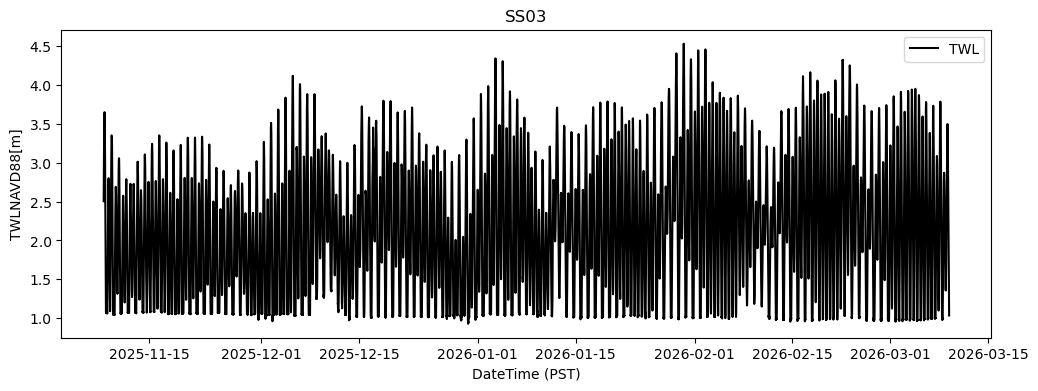

In [133]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(ss03_dt, ss03_twl, label='TWL', color='black')
ax.set_ylabel('TWLNAVD88[m]')
ax.set_xlabel('DateTime (PST)')
ax.set_title('SS03')
ax.legend();

## Skidmore Slough Timestack

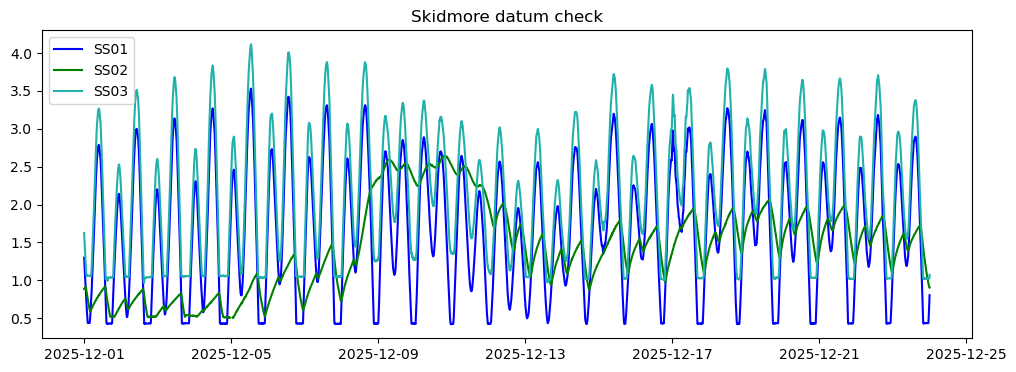

In [136]:
start = pd.Timestamp('2025-12-01')
end   = pd.Timestamp('2025-12-24')

m01   = (ss01_dt >= start) & (ss01_dt <= end)
m02   = (ss02_dt >= start) & (ss02_dt <= end)
m03   = (ss03_dt >= start) & (ss03_dt <= end)
# mwr01 = (wr01_dt >= start) & (wr01_dt <= end)

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title('Skidmore datum check')
ax.plot(ss01_dt[m01],   ss01_twl[m01],   color='blue', label='SS01')
ax.plot(ss02_dt[m02],   ss02_twl[m02],   color='green',  label='SS02')
ax.plot(ss03_dt[m03],   ss03_twl[m03],   color='lightseagreen',   label='SS03')
# ax.plot(wr01_dt[mwr01], wr01_twl[mwr01], color='black',  label='WR01')
ax.legend();

## **Create CSV**

In [139]:
combined_df = pd.concat([
    usgs_df_new[['USGS DATETIME [PST]', 'USGS TWL NAVD88 [m]']].reset_index(drop=True),
    TP_df_new[['TP DATETIME [PST]', 'TP TWL NAVD88 [m]']].reset_index(drop=True),
    wr01_df_new[['WR01 DATETIME [PST]', 'WR01 TWL [m]', 'WR01 OFFSET [m]', 'WR01 TWL NAVD88 [m]']].reset_index(drop=True),
    wr02_df_new[['WR02 DATETIME [PST]', 'WR02 TWL [m]', 'WR02 OFFSET [m]', 'WR02 TWL NAVD88 [m]']].reset_index(drop=True),
    wr03_df_new[['WR03 DATETIME [PST]', 'WR03 ABS PRESS [cmH2O]', 'WR03 ABS PRESS [Pa]', 'WR03 TEMP [degC]', 'WR03 MET PRESS [Pa]', 'WR03 TWL [m]', 'WR03 OFFSET [m]', 'WR03 TWL NAVD88 [m]']].reset_index(drop=True),
    wr04_df_new[['WR04 DATETIME [PST]', 'WR04 ABS PRESS [cmH2O]', 'WR04 ABS PRESS [Pa]', 'WR04 TEMP [degC]', 'WR04 MET PRESS [Pa]', 'WR04 TWL [m]', 'WR04 OFFSET [m]', 'WR04 TWL NAVD88 [m]']].reset_index(drop=True),
    wr06_p_df_new[['WR06 DATETIME [PST]', 'WR06 ABS PRESS [psi]', 'WR06 ABS PRESS [Pa]', 'WR06 TEMP [degC]', 'WR06 MET PRESS [Pa]', 'WR06 TWL [m]', 'WR06 OFFSET [m]', 'WR06 TWL NAVD88 [m]']].reset_index(drop=True),
    wr06_ctd_d3_df_new[['WR06 DATETIME [PST]', 'WR06 ABS PRESS [psi]', 'WR06 ABS PRESS [Pa]', 'WR06 TEMP [degC]', 'WR06 MET PRESS [Pa]', 'WR06 TWL [m]', 'WR06 OFFSET [m]', 'WR06 TWL NAVD88 [m]']].reset_index(drop=True),
    wr07_df_new[['WR07 DATETIME [PST]', 'WR07 ABS PRESS [psi]', 'WR07 ABS PRESS [Pa]', 'WR07 TEMP [degC]', 'WR07 MET PRESS [Pa]', 'WR07 TWL [m]', 'WR07 OFFSET [m]', 'WR07 TWL NAVD88 [m]']].reset_index(drop=True),
    wr08_df_new[['WR08 DATETIME [PST]', 'WR08 ABS PRESS [psi]', 'WR08 ABS PRESS [Pa]', 'WR08 TEMP [degC]', 'WR08 MET PRESS [Pa]', 'WR08 TWL [m]']].reset_index(drop=True),
    sf01_d4_df_new[['SF01 DATETIME [PST]', 'SF01 ABS PRESS [cmH2O]', 'SF01 ABS PRESS [Pa]', 'SF01 TEMP [degC]', 'SF01 MET PRESS [Pa]', 'SF01 TWL [m]', 'SF01 OFFSET [m]', 'SF01 TWL NAVD88 [m]']].reset_index(drop=True),
    sf01_d5_df_new[['SF01 DATETIME [PST]', 'SF01 ABS PRESS [cmH2O]', 'SF01 ABS PRESS [Pa]', 'SF01 TEMP [degC]', 'SF01 MET PRESS [Pa]', 'SF01 TWL [m]', 'SF01 OFFSET [m]', 'SF01 TWL NAVD88 [m]']].reset_index(drop=True),
    sf02_d4_df_new[['SF02 DATETIME [PST]', 'SF02 ABS PRESS [ftH2O]', 'SF02 ABS PRESS [Pa]', 'SF02 TEMP [degC]', 'SF02 MET PRESS [Pa]', 'SF02 TWL [m]', 'SF02 OFFSET [m]', 'SF02 TWL NAVD88 [m]']].reset_index(drop=True),
    sf03_df_new[['SF03 DATETIME [PST]', 'SF03 ABS PRESS [psi]', 'SF03 ABS PRESS [Pa]', 'SF03 approx TEMP [degC]', 'SF03 MET PRESS [Pa]', 'SF03 TWL [m]']].reset_index(drop=True),
    ss01_df_new[['SS01 DATETIME [PST]', 'SS01 ABS PRESS [Pa]', 'SS01 approx TEMP [degC]', 'SS01 MET PRESS [Pa]', 'SS01 TWL [m]', 'SS01 TWL NAVD88 [m]']].reset_index(drop=True),
    ss02_df_new[['SS02 DATETIME [PST]', 'SS02 ABS PRESS [Pa]', 'SS02 approx TEMP [degC]', 'SS02 MET PRESS [Pa]', 'SS02 TWL [m]', 'SS02 TWL NAVD88 [m]']].reset_index(drop=True),
    ss03_df_new[['SS03 DATETIME [PST]', 'SS03 ABS PRESS [Pa]', 'SS03 approx TEMP [degC]', 'SS03 MET PRESS [Pa]', 'SS03 TWL [m]', 'SS03 TWL NAVD88 [m]']].reset_index(drop=True),
], axis=1)

combined_df.head()

# ref at the beginning

,USGS DATETIME [PST],USGS TWL NAVD88 [m],TP DATETIME [PST],TP TWL NAVD88 [m],WR01 DATETIME [PST],WR01 TWL [m],WR01 OFFSET [m],WR01 TWL NAVD88 [m],WR02 DATETIME [PST],WR02 TWL [m],...,SS02 approx TEMP [degC],SS02 MET PRESS [Pa],SS02 TWL [m],SS02 TWL NAVD88 [m],SS03 DATETIME [PST],SS03 ABS PRESS [Pa],SS03 approx TEMP [degC],SS03 MET PRESS [Pa],SS03 TWL [m],SS03 TWL NAVD88 [m]
0,2026-05-01 06:45:00+00:00,1.255776,2025-11-06 00:00:00,2.478,2025-11-08 01:50:00,1.990344,-0.427,1.563344,2025-11-07 22:00:00,0.091440,...,9.589186,101998.333333,0.460844,0.964844,2025-11-08 11:45:00,124670.0,9.292579,101980.000000,2.312486,2.504486
1,2026-05-01 06:30:00+00:00,1.258824,2025-11-06 00:06:00,2.513,2025-11-08 01:55:00,2.036064,-0.427,1.609064,2025-11-07 22:05:00,0.103632,...,9.546670,101996.666667,0.464375,0.968375,2025-11-08 11:50:00,125241.0,9.260821,101976.666667,2.371014,2.563014
2,2026-05-01 06:15:00+00:00,1.258824,2025-11-06 00:12:00,2.549,2025-11-08 02:00:00,2.081784,-0.427,1.654784,2025-11-07 22:10:00,0.134112,...,9.505555,101995.000000,0.464543,0.968543,2025-11-08 11:55:00,125814.0,9.230388,101973.333333,2.429746,2.621746
3,2026-05-01 06:00:00+00:00,1.258824,2025-11-06 00:18:00,2.585,2025-11-08 02:05:00,2.130552,-0.427,1.703552,2025-11-07 22:15:00,0.164592,...,9.466154,101993.333333,0.466342,0.970342,2025-11-08 12:00:00,126316.0,9.199759,101970.000000,2.481242,2.673242
4,2026-05-01 05:45:00+00:00,1.258824,2025-11-06 00:24:00,2.616,2025-11-08 02:10:00,2.170176,-0.427,1.743176,2025-11-07 22:20:00,0.201168,...,9.428214,101991.666667,0.469874,0.973874,2025-11-08 12:05:00,126854.0,9.170364,101963.333333,2.536746,2.728746


In [141]:
combined_twl_df = pd.concat([
    usgs_df_new[['USGS DATETIME [PST]', 'USGS TWL NAVD88 [m]']].reset_index(drop=True),
    TP_df_new[['TP DATETIME [PST]', 'TP TWL NAVD88 [m]']].reset_index(drop=True),
    wr01_df_new[['WR01 DATETIME [PST]', 'WR01 TWL NAVD88 [m]']].reset_index(drop=True),
    wr02_df_new[['WR02 DATETIME [PST]', 'WR02 TWL NAVD88 [m]']].reset_index(drop=True),
    wr03_df_new[['WR03 DATETIME [PST]', 'WR03 TWL NAVD88 [m]']].reset_index(drop=True),
    wr04_df_new[['WR04 DATETIME [PST]', 'WR04 TWL NAVD88 [m]']].reset_index(drop=True),
    wr06_p_df_new[['WR06 DATETIME [PST]', 'WR06 TWL NAVD88 [m]']].reset_index(drop=True),
    wr06_ctd_d3_df_new[['WR06 DATETIME [PST]', 'WR06 TWL NAVD88 [m]']].reset_index(drop=True),
    wr07_df_new[['WR07 DATETIME [PST]', 'WR07 TWL NAVD88 [m]']].reset_index(drop=True),
    wr08_df_new[['WR08 DATETIME [PST]', 'WR08 TWL [m]']].reset_index(drop=True),          # no NAVD88
    sf01_d4_df_new[['SF01 DATETIME [PST]', 'SF01 TWL NAVD88 [m]']].reset_index(drop=True),
    sf01_d5_df_new[['SF01 DATETIME [PST]', 'SF01 TWL NAVD88 [m]']].reset_index(drop=True),
    sf02_d4_df_new[['SF02 DATETIME [PST]', 'SF02 TWL NAVD88 [m]']].reset_index(drop=True),
    sf03_df_new[['SF03 DATETIME [PST]', 'SF03 TWL [m]']].reset_index(drop=True),           # no NAVD88
    ss01_df_new[['SS01 DATETIME [PST]', 'SS01 TWL NAVD88 [m]']].reset_index(drop=True),
    ss02_df_new[['SS02 DATETIME [PST]', 'SS02 TWL NAVD88 [m]']].reset_index(drop=True),
    ss03_df_new[['SS03 DATETIME [PST]', 'SS03 TWL NAVD88 [m]']].reset_index(drop=True),
], axis=1)

combined_twl_df.head()

,USGS DATETIME [PST],USGS TWL NAVD88 [m],TP DATETIME [PST],TP TWL NAVD88 [m],WR01 DATETIME [PST],WR01 TWL NAVD88 [m],WR02 DATETIME [PST],WR02 TWL NAVD88 [m],WR03 DATETIME [PST],WR03 TWL NAVD88 [m],...,SF02 DATETIME [PST],SF02 TWL NAVD88 [m],SF03 DATETIME [PST],SF03 TWL [m],SS01 DATETIME [PST],SS01 TWL NAVD88 [m],SS02 DATETIME [PST],SS02 TWL NAVD88 [m],SS03 DATETIME [PST],SS03 TWL NAVD88 [m]
0,2026-05-01 06:45:00+00:00,1.255776,2025-11-06 00:00:00,2.478,2025-11-08 01:50:00,1.563344,2025-11-07 22:00:00,-0.335560,2025-11-06 08:10:00,0.904778,...,2025-11-07 08:50:00,1.042384,2025-11-25 17:15:00,0.210459,2025-11-08 10:05:00,1.157335,2025-11-08 11:05:00,0.964844,2025-11-08 11:45:00,2.504486
1,2026-05-01 06:30:00+00:00,1.258824,2025-11-06 00:06:00,2.513,2025-11-08 01:55:00,1.609064,2025-11-07 22:05:00,-0.323368,2025-11-06 08:15:00,0.949878,...,2025-11-07 08:55:00,1.078794,2025-11-25 17:20:00,0.214032,2025-11-08 10:10:00,1.194262,2025-11-08 11:10:00,0.968375,2025-11-08 11:50:00,2.563014
2,2026-05-01 06:15:00+00:00,1.258824,2025-11-06 00:12:00,2.549,2025-11-08 02:00:00,1.654784,2025-11-07 22:10:00,-0.292888,2025-11-06 08:20:00,1.001964,...,2025-11-07 09:00:00,1.115220,2025-11-25 17:25:00,0.219292,2025-11-08 10:15:00,1.241584,2025-11-08 11:15:00,0.968543,2025-11-08 11:55:00,2.621746
3,2026-05-01 06:00:00+00:00,1.258824,2025-11-06 00:18:00,2.585,2025-11-08 02:05:00,1.703552,2025-11-07 22:15:00,-0.262408,2025-11-06 08:25:00,1.058731,...,2025-11-07 09:05:00,1.141366,2025-11-25 17:30:00,0.219632,2025-11-08 10:20:00,1.282077,2025-11-08 11:20:00,0.970342,2025-11-08 12:00:00,2.673242
4,2026-05-01 05:45:00+00:00,1.258824,2025-11-06 00:24:00,2.616,2025-11-08 02:10:00,1.743176,2025-11-07 22:20:00,-0.225832,2025-11-06 08:30:00,1.116651,...,2025-11-07 09:10:00,1.175101,2025-11-25 17:35:00,0.219802,2025-11-08 10:25:00,1.329501,2025-11-08 11:25:00,0.973874,2025-11-08 12:05:00,2.728746


In [182]:
combined_df.to_csv('lowill_complete_dataset.csv', index=False)